# Winning a Stock-Picking Competition with Simulation

**The assignment.** In a university investment class, each student picks 10 stocks, explains each pick, and splits a hypothetical \$100,000 among them. The portfolio is bought at the close on **Sep 14, 2026** and valued at the close on **Dec 14, 2026**. The highest return wins.

**Rules.** All 10 stocks must be held, each at **5–20%** of the portfolio. Buy once and hold. Fractional shares are allowed.

**The questions.**
1. *How should the money be split across the 10 chosen stocks to give the best chance of finishing first?*
2. *What kind of portfolio actually wins contests like this, and how much would free stock choice have helped?*

**Why this isn't a normal investing problem.** Textbook portfolio theory maximizes return per unit of risk (the Sharpe ratio). A winner-take-all contest is different: with 20 rivals, someone with a risky mix usually gets lucky, so a steady portfolio almost never finishes first. What matters is the **probability of beating every rival**, written **P(win)** in this notebook.

**Method**
1. Simulate up to a million possible 3-month futures, built from real price history.
2. In each future, simulate 20 rival students with their own random stocks and weights, and record what the winners held.
3. Score every allowed way to split the money across our 10 stocks by how often it finishes first, then fine-tune the best ones.
4. Search about 550 stocks for the best possible 10-stock portfolio, as if the picks had been free.
5. Test how much the answers depend on who the rivals are.
6. Check the method on past quarters (a backtest).

> **Just want the answer?** The notebook is saved with its results. Jump to **section 12 (Final allocation)** and **section 13 (What we learned)**.

| Section | Contents |
| --- | --- |
| Key terms | Short definitions of the finance and statistics terms used |
| 1 | Settings |
| 2 | Price data |
| 3 | The 10 stocks: why they were picked, and what the data says |
| 4 | Simulating 3-month returns |
| 5 | The simulated rivals, and who wins |
| 6 | Searching all 5.3 million allowed portfolios |
| 7 | Fine-tuning at 1% steps |
| 8 | Comparison with standard portfolios |
| 9 | Free choice: the best 10 stocks from about 550 |
| 10 | How much do the rival assumptions matter? |
| 11 | Backtest on past quarters |
| 12 | Final allocation |
| 13 | What we learned |
| 14 | Lessons, caveats and experiments to try |

## Key terms

| Term | Meaning |
| --- | --- |
| **Return** | Percentage gain or loss over a period, including dividends |
| **Volatility** | How much a price swings: the standard deviation of returns, scaled to a year |
| **Beta** | How much a stock tends to move when the market moves 1%. Beta 2 means about 2%. |
| **Correlation** | How closely two stocks move together, from −1 (opposite) to +1 (in lockstep) |
| **Diversification** | Holding stocks that don't move together, which narrows the range of outcomes |
| **Max drawdown** | The largest fall from a peak to a later low |
| **Momentum** | The tendency of recent winners to keep rising for a while. Measured here as the 12-month return excluding the latest month. |
| **Risk-free rate** | The return on 13-week US Treasury bills |
| **Equity risk premium** | The extra annual return investors expect from stocks over T-bills (5% assumed) |
| **CAPM** | Capital Asset Pricing Model: expected return = risk-free rate + beta × equity risk premium |
| **Sharpe ratio** | Return above the risk-free rate divided by volatility: return per unit of risk |
| **Analyst target** | The average 12-month price forecast of Wall Street analysts covering a stock |
| **Monte Carlo simulation** | Estimating probabilities by generating many random possible outcomes |
| **Bootstrap** | Building new samples by re-drawing pieces of the real data at random |
| **P(win)** | The share of simulated futures in which a portfolio beats all 20 rivals |
| **Lift** | How much more often winning portfolios hold a stock than portfolios in general. A lift of 1.5 means 50% more often. |
| **Percentile** | The 90th percentile is the value that 90% of outcomes fall below |
| **Backtest** | Testing a strategy on past data, using only what was known at each date |

## 1. Settings

Everything you can change is in the second cell below. Set `QUICK_MODE = True` for a fast test run of about a minute. The full run takes about 15 minutes on a recent 10-core laptop (longer with fewer cores) and uses up to about 4 GB of memory. Downloads and the slowest results are cached in `data/`, so a same-day rerun is quicker.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from stock_competition import (backtest, cache, charts, data, picks, rivals, scenarios, search, simulation, stats,
                               universe)
from stock_competition.market_calendar import trading_days
from stock_competition.paths import RESULTS_DIR
from stock_competition.scenarios import VIEW_LABELS
from stock_competition.settings import StrategySettings

%config InlineBackend.figure_format = "retina"
charts.set_chart_style()

In [2]:
# Competition rules
CAPITAL = 100_000
TICKERS = ["AAPL", "NVDA", "BSY", "SNAP", "JPM", "NEE", "DE", "CAT", "GOOGL", "COST"]
MIN_WEIGHT, MAX_WEIGHT = 0.05, 0.20
START, END = "2026-09-14", "2026-12-14"   # buy at the START close; final value at the END close
BENCHMARK = "SPY"                          # S&P 500 ETF: used for beta and as a reference point

# Rivals: other students, each holding 10 stocks under the same rules
N_RIVALS = 20
RIVAL_UNIVERSE = list(universe.POPULAR_STOCKS)  # about 200 well-known stocks

# Free choice: every stock the search may pick (S&P 500, Nasdaq-100, meme and crypto stocks, the rival pool)
CANDIDATE_UNIVERSE = list(universe.POPULAR_STOCKS) + list(universe.INDEX_STOCKS) + list(universe.SPECULATIVE_STOCKS)

# Search size
QUICK_MODE = False                                    # True: coarser grid and fewer simulations (~1 minute)
GRID_STEP = 0.05 if QUICK_MODE else 0.025             # 2.5% steps -> 5,266,030 allowed portfolios
N_SIMS_SCREEN = 5_000 if QUICK_MODE else 50_000       # stage 1: simulations for every grid portfolio
TOP_K_CONFIRM = 2_000 if QUICK_MODE else 20_000       # stage 2: best candidates per view carried forward
N_SIMS_CONFIRM = 50_000 if QUICK_MODE else 1_000_000  # stages 2-3: fresh simulations for candidates
FINE_STEP = 0.01                                      # stage 3: fine-tuning step
N_SIMS_FREE = 20_000 if QUICK_MODE else 100_000       # free-choice search and its validation
BACKTEST_GRID_STEP = 0.05 if QUICK_MODE else 0.025
BACKTEST_SIMS = 2_000 if QUICK_MODE else 10_000

# Simulation model
BLOCK_DAYS = 21               # bootstrap block length: one trading month
HISTORY_START = "max"         # or a date such as "2022-01-01"
IPO_SKIP_DAYS = 20            # skip the first trading days after the newest stock's IPO (BSY)
HALF_LIFE_YEARS = None        # e.g. 2 to weight recent years more; None weights all years equally
EQUITY_PREMIUM = 0.05         # expected annual return of stocks above T-bills
MOMENTUM_TILT = 0.04          # extra annual return per 1 standard deviation of momentum
ANALYST_SHRINK = 0.25         # share of the analyst-target upside we believe
RISK_FREE_FALLBACK = 0.04     # used only if the T-bill yield can't be downloaded
VIEW_WEIGHTS = {"neutral": 1, "momentum": 1, "analyst": 1, "trend": 1}
FREE_VIEW_WEIGHTS = {"neutral": 1, "momentum": 1, "trend": 1}  # no analyst view: targets for ~550 stocks are slow

SEED = 42
REFRESH_DATA = False          # True forces a fresh download even if today's data is cached

## 2. Price data

Daily closing prices adjusted for splits and dividends come from Yahoo Finance.

The simulation needs **all stocks on the same dates**, so its history window starts when the newest of our stocks began trading. Bentley Systems (BSY) listed on Sep 23, 2020, which leaves about 6 years. The first 20 trading days after that IPO are skipped because prices swing unusually in the weeks after a listing. Rival-pool and candidate stocks without complete prices over the window are dropped; most of those listed after 2020.

In [3]:
rival_only = [t for t in dict.fromkeys(RIVAL_UNIVERSE) if t not in TICKERS]
other_candidates = [t for t in dict.fromkeys(CANDIDATE_UNIVERSE) if t not in TICKERS and t not in rival_only]
our_prices = data.load_prices(TICKERS + [BENCHMARK], refresh=REFRESH_DATA)  # full history, for the charts
window_start = data.shared_window_start(our_prices, TICKERS, IPO_SKIP_DAYS, HISTORY_START)
other_prices = data.load_prices(rival_only + other_candidates, start=f"{window_start - pd.Timedelta(days=30):%Y-%m-%d}",
                                refresh=REFRESH_DATA)
irx = data.load_prices(["^IRX"], refresh=REFRESH_DATA)["^IRX"].dropna()  # 13-week T-bill yield, in percent

window, dropped = data.window_prices(our_prices.join(other_prices, how="outer"), TICKERS + [BENCHMARK],
                                     rival_only + other_candidates, window_start)
RIVALS_KEPT = [t for t in rival_only if t in window.columns]
POOL = TICKERS + RIVALS_KEPT                                   # stocks a rival can hold
CANDIDATES = POOL + [t for t in other_candidates if t in window.columns]
prices = window[POOL + [BENCHMARK]]                            # main analysis: our stocks, rival pool, benchmark
candidate_prices = window[CANDIDATES + [BENCHMARK]]            # free-choice search
N = len(TICKERS)

HORIZON = len(trading_days(START, END))
RISK_FREE = irx.iloc[-1] / 100 if len(irx) else RISK_FREE_FALLBACK
RISK_FREE_HORIZON = (1 + RISK_FREE) ** (HORIZON / 252) - 1
LAST_DATE = prices.index[-1]
SETTINGS = StrategySettings(
    horizon=HORIZON, min_weight=MIN_WEIGHT, max_weight=MAX_WEIGHT, n_rivals=N_RIVALS, block_days=BLOCK_DAYS,
    equity_premium=EQUITY_PREMIUM, momentum_tilt=MOMENTUM_TILT, risk_free_fallback=RISK_FREE_FALLBACK,
    half_life_days=HALF_LIFE_YEARS * 252 if HALF_LIFE_YEARS else None,
)

print(f"History window: {window_start:%Y-%m-%d} → {LAST_DATE:%Y-%m-%d} ({len(prices) - 1:,} daily returns)")
print(f"Competition horizon: {HORIZON} trading days · 13-week T-bill yield: {RISK_FREE:.2%}")
print(f"Rival pool: {len(POOL)} stocks · free-choice candidates: {len(CANDIDATES)} stocks")
print(f"Dropped for incomplete history ({len(dropped)}): {', '.join(dropped) or 'none'}")

first_day = pd.to_datetime(pd.Series({t: our_prices[t].first_valid_index() for t in TICKERS}))
history = pd.DataFrame({
    "first trading day": first_day.dt.strftime("%Y-%m-%d"),
    "years of history": (LAST_DATE - first_day).dt.days / 365.25,
    "missing days in window": prices[TICKERS].isna().sum(),
}).sort_values("first trading day")
display(history.style.format({"years of history": "{:.1f}"}))

History window: 2020-10-21 → 2026-09-11 (1,478 daily returns)
Competition horizon: 64 trading days · 13-week T-bill yield: 3.91%
Rival pool: 205 stocks · free-choice candidates: 555 stocks
Dropped for incomplete history (14): ABNB, APP, ARM, CEG, COIN, DASH, EXE, GEHC, GEV, GFS, HOOD, KVUE, SOLV, VLTO


,first trading day,years of history,missing days in window
CAT,1962-01-02,64.7,0
DE,1972-06-01,54.3,0
NEE,1973-02-21,53.6,0
JPM,1980-03-17,46.5,0
AAPL,1980-12-12,45.7,0
COST,1986-07-09,40.2,0
NVDA,1999-01-22,27.6,0
GOOGL,2004-08-19,22.1,0
SNAP,2017-03-02,9.5,0
BSY,2020-09-23,6.0,0


## 3. The 10 stocks: why they were picked, and what the data says

The assignment asked for a short reason behind each pick. Here they are, lightly edited, next to a sector check.

| # | Stock | Sector | Reason for the pick |
| --- | --- | --- | --- |
| 1 | **AAPL** Apple | Technology | One of the largest companies in the world, and a familiar long-term holding |
| 2 | **NVDA** NVIDIA | Technology (semiconductors) | The market's hottest stock, with years of strong results; a way to follow a leading company |
| 3 | **BSY** Bentley Systems | Technology (engineering software) | A family connection to the company made it interesting to follow |
| 4 | **SNAP** Snap Inc. | Communication services | Years of weak performance despite an app used by most of Gen Z; a bet that it learns to earn money from it and recovers |
| 5 | **JPM** JPMorgan Chase | Financials | One of the biggest banks in the world, seen as a safe holding that balances a tech-heavy list |
| 6 | **NEE** NextEra Energy | Utilities *(listed as Energy in the original notes)* | Added for diversification |
| 7 | **DE** Deere & Company | Industrials | Analyzed in a managerial-accounting class presentation; chosen to see how it keeps performing |
| 8 | **CAT** Caterpillar | Industrials | Same class analysis, which rated it the stronger company of the two; also adds diversification |
| 9 | **GOOGL** Alphabet | Communication services | A popular AI company with strong recent profits; a way to ride the AI wave |
| 10 | **COST** Costco | Consumer staples | Adds a consumer stock; a favorite place to shop |

Checking a story against the data is a good habit. The table below measures each stock over the history window.

In [4]:
stock_table = stats.stock_stats(prices, TICKERS + [BENCHMARK], BENCHMARK, HORIZON)
stock_table.insert(3, "avg_correlation", stats.average_correlation(prices, TICKERS))
display(stock_table.style.format("{:.1%}", na_rep="–")
        .format("{:.2f}", subset=pd.Index(["beta", "avg_correlation"])))

,annual_return,annual_vol,beta,avg_correlation,max_drawdown,momentum_12_1,64d_return_p5,64d_return_median,64d_return_p95
AAPL,20.1%,27.9%,1.16,0.34,-33.4%,33.8%,-13.8%,4.7%,24.2%
NVDA,60.8%,50.1%,2.00,0.32,-66.3%,26.5%,-25.8%,13.0%,66.3%
BSY,-2.9%,37.9%,1.12,0.27,-61.0%,-31.7%,-25.5%,-0.6%,31.6%
SNAP,-27.2%,76.8%,1.60,0.24,-95.3%,-26.2%,-48.8%,-7.3%,45.8%
JPM,27.4%,24.8%,1.01,0.29,-38.8%,23.8%,-13.1%,6.1%,24.5%
NEE,4.4%,26.4%,0.58,0.17,-45.0%,23.3%,-13.6%,0.3%,19.5%
DE,21.1%,29.7%,0.87,0.26,-33.8%,33.1%,-13.2%,4.4%,27.5%
CAT,33.5%,31.1%,1.01,0.29,-34.0%,104.1%,-14.8%,8.3%,37.5%
GOOGL,28.3%,31.2%,1.21,0.33,-44.3%,43.9%,-17.1%,7.9%,35.0%
COST,17.8%,22.3%,0.75,0.26,-31.4%,-0.1%,-10.1%,5.4%,21.8%


**Reading the columns.** `annual_return` is the compound annual growth rate. `avg_correlation` is the stock's average correlation with the other nine picks. The last three columns summarize every historical 64-trading-day holding period in the window: the 5th percentile, the median and the 95th percentile.

**What the data says** (figures from the saved run, prices through Sep 11, 2026)
- **The list leans on technology, and the diversifiers mostly work.** AAPL, NVDA and GOOGL move together (correlations around 0.5). JPM, NEE, DE and CAT correlate only about 0.1–0.3 with them, so they do spread the risk. COST is the exception: it moves fairly closely with AAPL (0.43).
- **NEE is a utility, not an energy company.** It still does its job: it is the least correlated stock on the list.
- **JPM is solid but not low-risk.** Its beta is about 1.0, so it moves roughly with the market, and it fell about 39% from peak to low during this window.
- **DE and CAT move together** (correlation 0.60), so owning both adds less diversification than two unrelated stocks would. CAT has the strongest momentum of the ten.
- **SNAP is by far the riskiest pick:** about 77% annual volatility and a 95% fall from its peak. As later sections show, a very volatile stock is valuable in a winner-take-all contest even without an optimistic forecast.
- **NVDA has the highest beta (about 2):** it tends to move twice as much as the market.
- **BSY has been a bumpy ride:** slightly negative annual return since listing and a 61% drawdown.
- **COST is the steadiest of the ten**, with the lowest volatility.

### Full price history
**How to read this chart:** each panel shows one stock's adjusted price since it listed, on a log scale, so equal vertical distances are equal percentage moves. The shaded area is the history window used by the simulation.

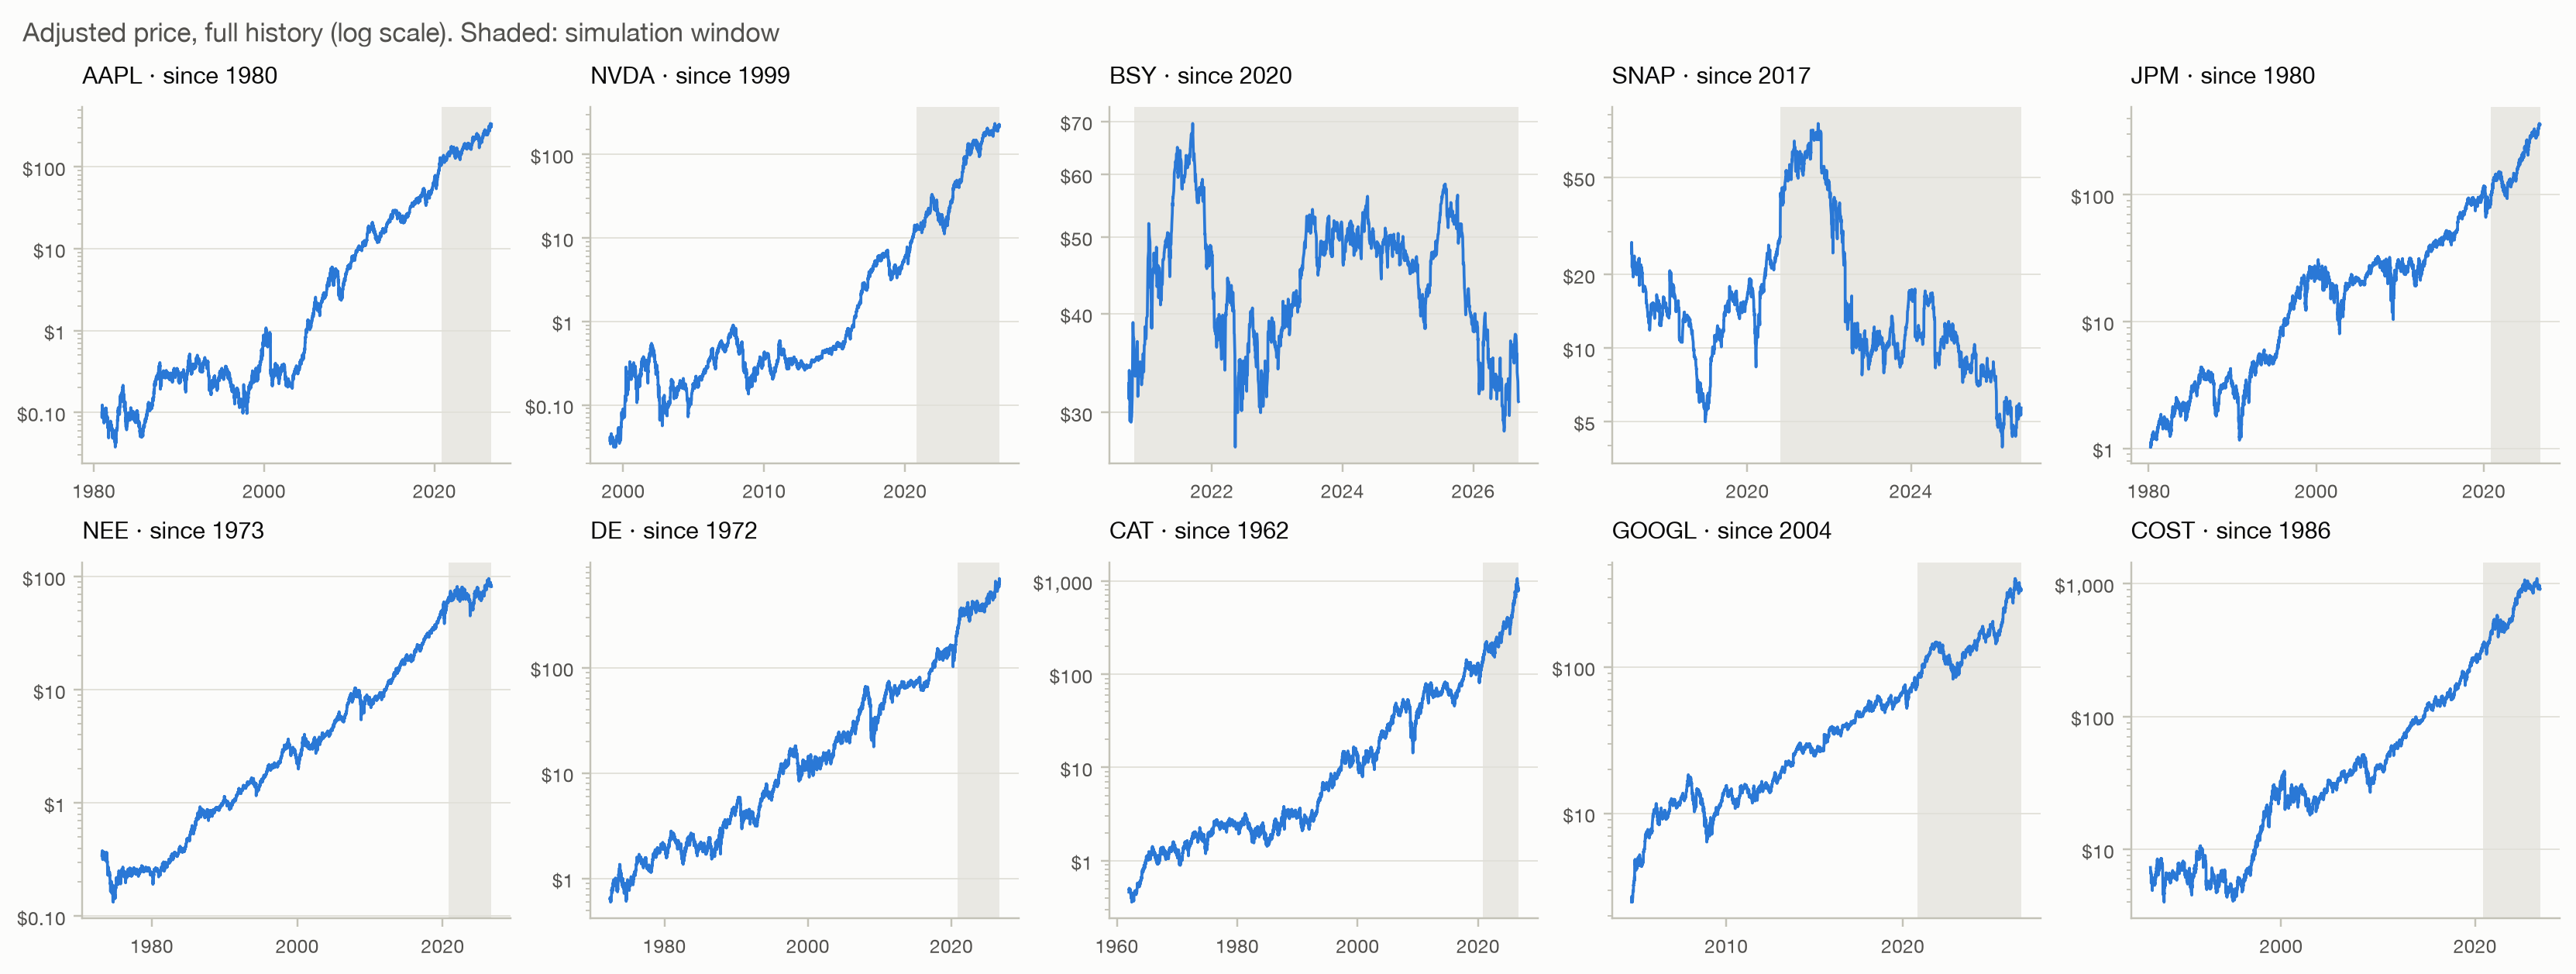

In [5]:
charts.price_history_grid(our_prices, TICKERS, window_start, LAST_DATE)
plt.show()

### How closely the stocks move together
**How to read this chart:** each cell is the correlation of daily returns between two stocks. Darker red means they move more alike. Blue would mean they tend to move in opposite directions; no pair here does.

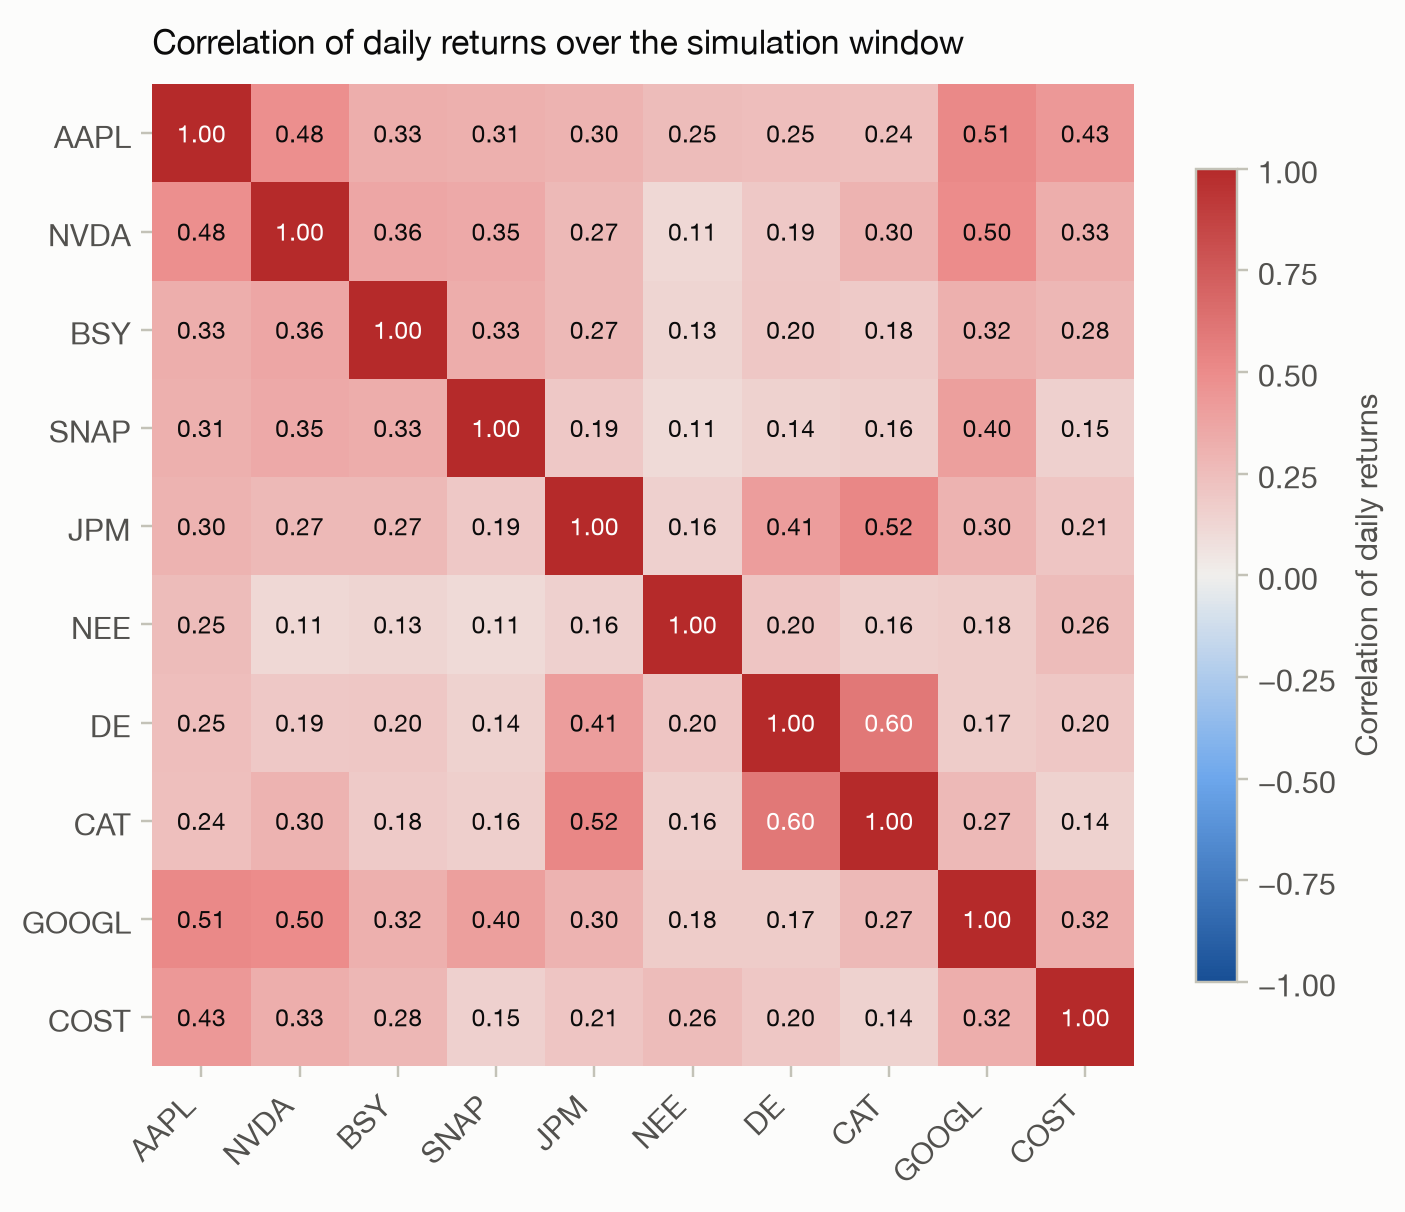

In [6]:
correlations = stats.log_returns(prices.reindex(columns=TICKERS)).dropna().corr()
charts.correlation_heatmap(correlations, "Correlation of daily returns over the simulation window")
plt.show()

### Earnings reports during the competition
Earnings days bring the biggest single-day moves. The simulation samples real history, which includes about four earnings seasons a year, so these jumps are already built in. This table is for information.

In [7]:
earnings = data.next_earnings(TICKERS, START, END)
display(earnings.style.format(
    {"next_earnings": lambda d: f"{d:%Y-%m-%d}" if isinstance(d, pd.Timestamp) else "unknown"}
))

,next_earnings,in_competition_window
ticker,,
AAPL,2026-10-29,True
NVDA,2026-11-17,True
BSY,2026-11-04,True
SNAP,2026-11-04,True
JPM,2026-10-13,True
NEE,2026-10-27,True
DE,2026-11-25,True
CAT,2026-10-29,True
GOOGL,2026-10-28,True


## 4. Simulating 3-month returns

**Block bootstrap.** Each simulated 3-month future is stitched together from random **1-month chunks of real history**. All stocks (ours, the rivals' and SPY) are drawn on the **same dates**, so real correlations, crashes and earnings seasons carry over. One-month chunks also keep the tendency of prices to partly reverse within a few weeks; shorter 10-day chunks overstated 3-month volatility by about 17% for SPY.

**Expected returns.** A stock's average past return is a poor forecast; used directly, the model would just pick recent winners. So the simulations are shifted to match several *views* of expected return. Volatility and correlations are the same in every view.

| View | Expected return per stock |
| --- | --- |
| **Neutral (CAPM)** | T-bill rate + beta × 5% equity premium. Only risk separates the stocks. |
| **Momentum** | Neutral + 4% a year per standard deviation of momentum |
| **Analyst targets** | Neutral + 25% of the upside to the analyst price target, relative to the median stock |
| **Historical trend** | No shift: each stock keeps its average return over the window (the optimistic "trend continues" case) |

The final choice averages over all four views, so it doesn't depend on any single forecast. The simulation code lives in `stock_competition/simulation.py`; the cell below calls it.

In [8]:
analyst_targets = data.load_analyst_targets(POOL, refresh=REFRESH_DATA)
targets, target_details = scenarios.drift_scenarios(prices, prices.columns, BENCHMARK, SETTINGS, RISK_FREE,
                                                    analyst_targets, ANALYST_SHRINK)
if VIEW_WEIGHTS.get("analyst") and "analyst" not in targets.columns:
    print("Too few analyst targets available today: the analyst view is skipped.")
VIEW_WEIGHTS_USED = {v: w for v, w in VIEW_WEIGHTS.items() if v == "trend" or v in targets.columns}
LOG_RETURNS = stats.log_returns(prices).iloc[1:]


def run_simulation(n_sims, seed, profile=False):
    """Simulate the competition, keeping our stocks and the benchmark; rivals pick from the pool."""
    return simulation.simulate(LOG_RETURNS, targets, SETTINGS, n_sims=n_sims, seed=seed, keep=TICKERS + [BENCHMARK],
                               pool=POOL, view_weights=VIEW_WEIGHTS_USED, profile=profile)


screen = run_simulation(N_SIMS_SCREEN, SEED, profile=True)
VIEWS = screen.views

expected_returns = pd.DataFrame(
    {VIEW_LABELS[v]: screen.returns[v].mean(axis=0, dtype=np.float64) for v in VIEWS}, index=screen.columns
)
inputs = target_details.loc[screen.columns, [c for c in ("beta", "momentum_12_1", "analyst_upside")
                                             if c in target_details]]
display(inputs.join(expected_returns).style
        .set_caption(f"Inputs, and the expected return over the {HORIZON}-day competition in each view")
        .format("{:.1%}", na_rep="–").format("{:.2f}", subset=pd.Index(["beta"])))

,beta,momentum_12_1,analyst_upside,Neutral (CAPM),Momentum,Analyst targets,Historical trend
AAPL,1.16,33.8%,-2.0%,2.4%,2.5%,1.1%,5.5%
NVDA,2.00,26.5%,49.9%,3.4%,3.4%,5.1%,16.6%
BSY,1.12,-31.7%,43.6%,2.3%,1.5%,3.8%,1.7%
SNAP,1.60,-26.2%,30.0%,2.9%,2.2%,3.5%,-3.2%
JPM,1.01,23.8%,5.6%,2.2%,2.2%,1.4%,6.9%
NEE,0.58,23.3%,19.5%,1.7%,1.7%,1.7%,2.2%
DE,0.87,33.1%,1.9%,2.0%,2.2%,1.0%,5.7%
CAT,1.01,104.1%,19.2%,2.2%,3.3%,2.2%,9.0%
GOOGL,1.21,43.9%,26.5%,2.4%,2.7%,2.9%,7.5%
COST,0.75,-0.1%,18.5%,1.9%,1.5%,1.9%,5.2%


**How to read this table:** the first columns are the inputs behind each view; the rest are the expected returns over the whole competition, not per year. Under the neutral view, NVDA and SNAP expect more because their high beta means more market risk.

### Sanity checks
1. **Volatility:** simulated 64-day volatility should be close to that of real historical 64-day periods. The historical figure is itself uncertain by about ±15% (six years hold only about 23 separate 3-month periods), so the check only flags gaps above 25%.
2. **Means:** simulated mean returns must equal each view's targets (true by construction, so this checks the code).
3. **Fairness:** if "we" are just one more random rival, P(win) must be about 1 / (rivals + 1). This checks the win-counting code.

In [9]:
hist_vol = stats.log_returns(prices.reindex(columns=screen.columns), HORIZON).std()
sim_vol = pd.Series(np.log1p(screen.returns[VIEWS[0]]).std(axis=0), index=screen.columns)
vol_check = pd.DataFrame({"historical": hist_vol, "simulated": sim_vol, "ratio": sim_vol / hist_vol})
display(vol_check.style.set_caption(f"{HORIZON}-day log-return volatility")
        .format({"historical": "{:.1%}", "simulated": "{:.1%}", "ratio": "{:.2f}"}))
benchmark_ratio = float(sim_vol[BENCHMARK] / hist_vol[BENCHMARK])
assert 0.75 <= benchmark_ratio <= 1.25, "Simulated SPY volatility is off by more than 25%"

mean_gap = max(
    np.abs(screen.returns[v].mean(axis=0, dtype=np.float64) - targets[v].loc[screen.columns].to_numpy()).max()
    for v in VIEWS if v in targets.columns
)
print(f"Largest gap between simulated and target mean return: {mean_gap:.1e}")
assert mean_gap < 1e-4

check_totals, check_expected = scenarios.bootstrap_log_returns(LOG_RETURNS.to_numpy(), HORIZON, 50_000, BLOCK_DAYS,
                                                               np.random.default_rng(SEED + 99))
check_returns = scenarios.apply_view(check_totals, check_expected,
                                     targets["neutral"].reindex(prices.columns).to_numpy())
every_rival = rivals.rival_returns(check_returns[:, :len(POOL)], N_RIVALS + 1, SEED + 99, N, MIN_WEIGHT, MAX_WEIGHT)
p_self = (every_rival[:, 0] > every_rival[:, 1:].max(axis=1)).mean()
print(f"P(win) of a random rival against {N_RIVALS} others: {p_self:.2%} (should be about {1 / (N_RIVALS + 1):.2%})")
assert abs(p_self - 1 / (N_RIVALS + 1)) < 0.006

,historical,simulated,ratio
AAPL,11.6%,12.8%,1.10
NVDA,24.5%,24.2%,0.99
BSY,16.7%,17.9%,1.07
SNAP,32.8%,34.4%,1.05
JPM,10.9%,11.6%,1.07
NEE,11.1%,13.5%,1.22
DE,12.3%,13.2%,1.08
CAT,15.6%,15.7%,1.01
GOOGL,14.8%,14.4%,0.97
COST,9.5%,11.8%,1.25


Largest gap between simulated and target mean return: 2.0e-09
P(win) of a random rival against 20 others: 4.72% (should be about 4.76%)


**Result:** simulated volatility is close to history for most stocks, means match exactly, and a random rival wins about 1 time in 21, as it should.

## 5. The simulated rivals, and who wins

Each simulated future contains **20 rivals**. Every rival holds 10 random stocks from a pool of about 200 well-known names, with random weights under the same 5–20% rules. Rivals live in the same simulated market as us: when the market crashes in one future, it crashes for everyone.

The number that matters is the **winning rival's return**: to win, our portfolio has to beat it.

,winning rival: 10th pct,winning rival: median,winning rival: 90th pct,3rd-best rival: median
Neutral (CAPM),-0.0%,13.9%,32.7%,8.7%
Momentum,-0.1%,13.8%,32.7%,8.7%
Analyst targets,0.1%,14.1%,33.0%,8.9%
Historical trend,2.8%,17.2%,37.1%,11.7%


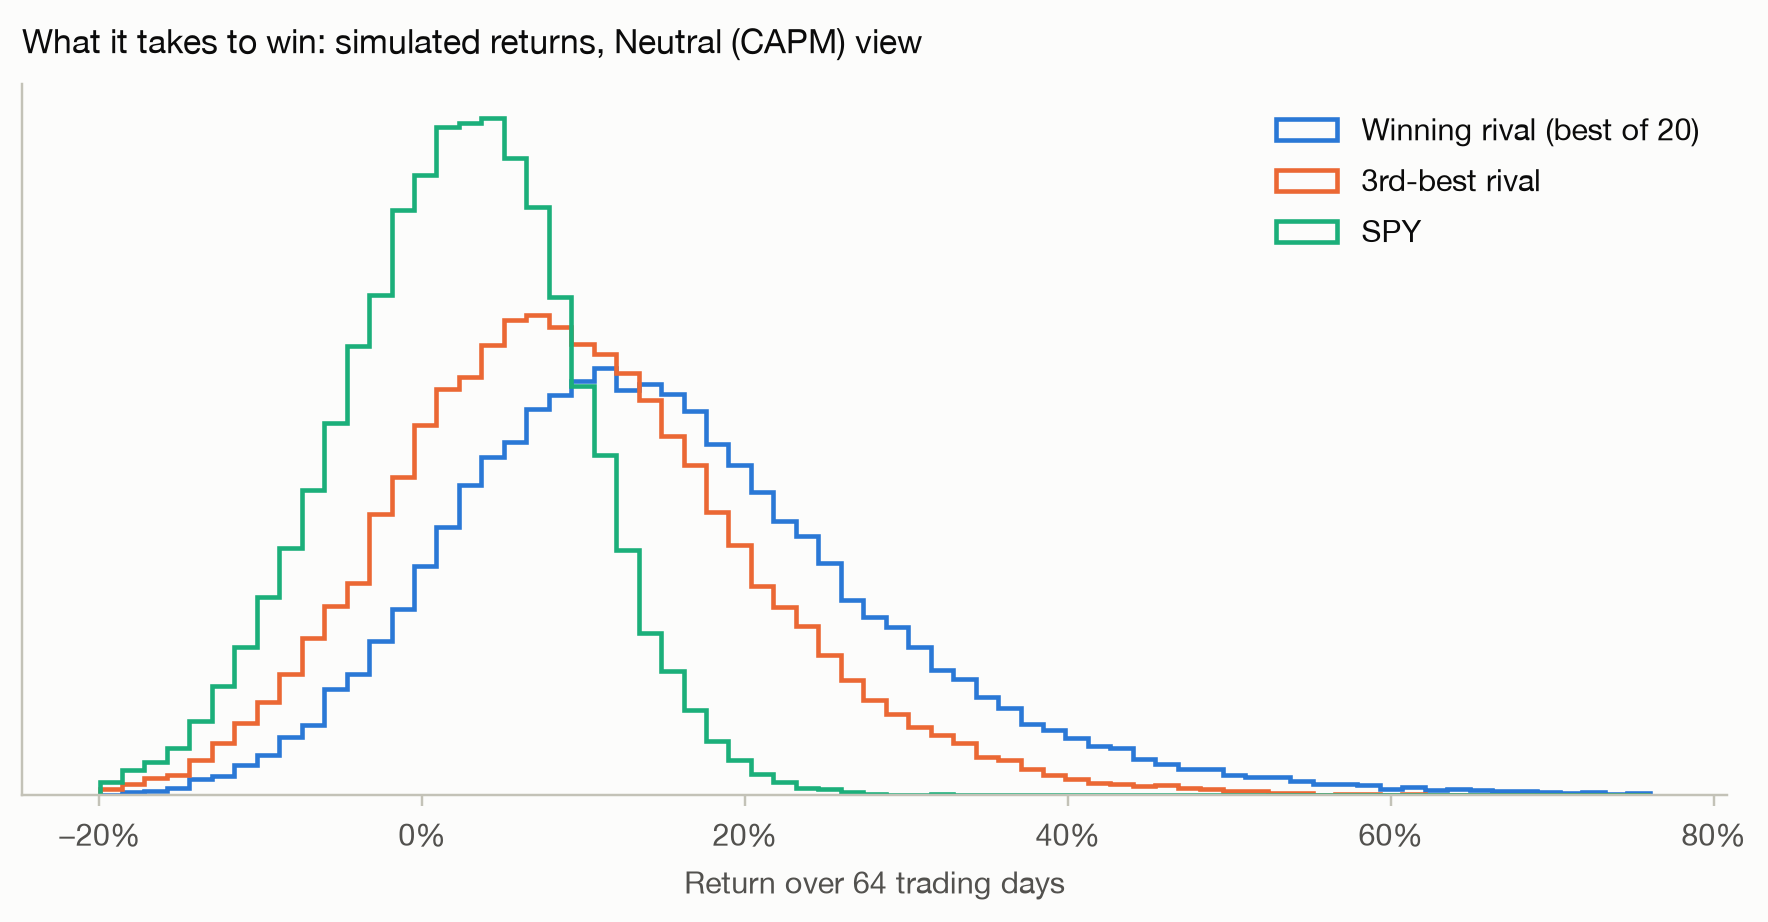

In [10]:
field_table = pd.DataFrame({
    VIEW_LABELS[v]: {
        "winning rival: 10th pct": np.percentile(screen.fields[v].best, 10),
        "winning rival: median": np.median(screen.fields[v].best),
        "winning rival: 90th pct": np.percentile(screen.fields[v].best, 90),
        "3rd-best rival: median": np.median(screen.fields[v].third),
    }
    for v in VIEWS
}).T
display(field_table.style.set_caption(f"Returns over {HORIZON} trading days").format("{:.1%}"))

charts.distributions({"Winning rival (best of 20)": screen.fields[VIEWS[0]].best,
                      "3rd-best rival": screen.fields[VIEWS[0]].third,
                      BENCHMARK: screen.returns[VIEWS[0]][:, N]},
                     f"Return over {HORIZON} trading days",
                     f"What it takes to win: simulated returns, {VIEW_LABELS[VIEWS[0]]} view", bins=70)
plt.show()

**How to read this chart:** each line is a distribution over simulated futures; higher means more likely. The market (SPY) typically returns a few percent in 3 months, but the *best of 20 rivals* typically returns over 10%. A portfolio that merely tracks the market would almost never win.

### Who wins? What the winning rivals held
In every simulated future, the notebook records the **winning rival's 10 stocks and weights**. Every stock is equally likely to be picked by a rival, so any stock that shows up more often among *winners* is one that helps win. **Lift** measures this: a lift of 1.5 means winners held the stock 50% more often than rivals in general.

,held by rivals,held by winners,lift,avg weight (rivals),avg weight (winners),annual_vol
ticker,,,,,,
CVNA,4.8%,7.3%,1.52,10.0%,11.0%,103%
SMCI,4.9%,7.2%,1.47,10.0%,10.8%,83%
MRNA,4.9%,6.9%,1.42,10.0%,10.8%,81%
CELH,4.9%,6.2%,1.27,10.0%,10.6%,69%
XPEV,4.9%,6.2%,1.26,10.0%,10.8%,80%
PLTR,4.9%,5.9%,1.21,10.0%,10.6%,69%
PDD,4.8%,5.7%,1.19,10.0%,10.4%,67%
W,4.9%,5.7%,1.17,10.0%,10.5%,79%
ENPH,4.9%,5.7%,1.16,10.0%,10.6%,70%


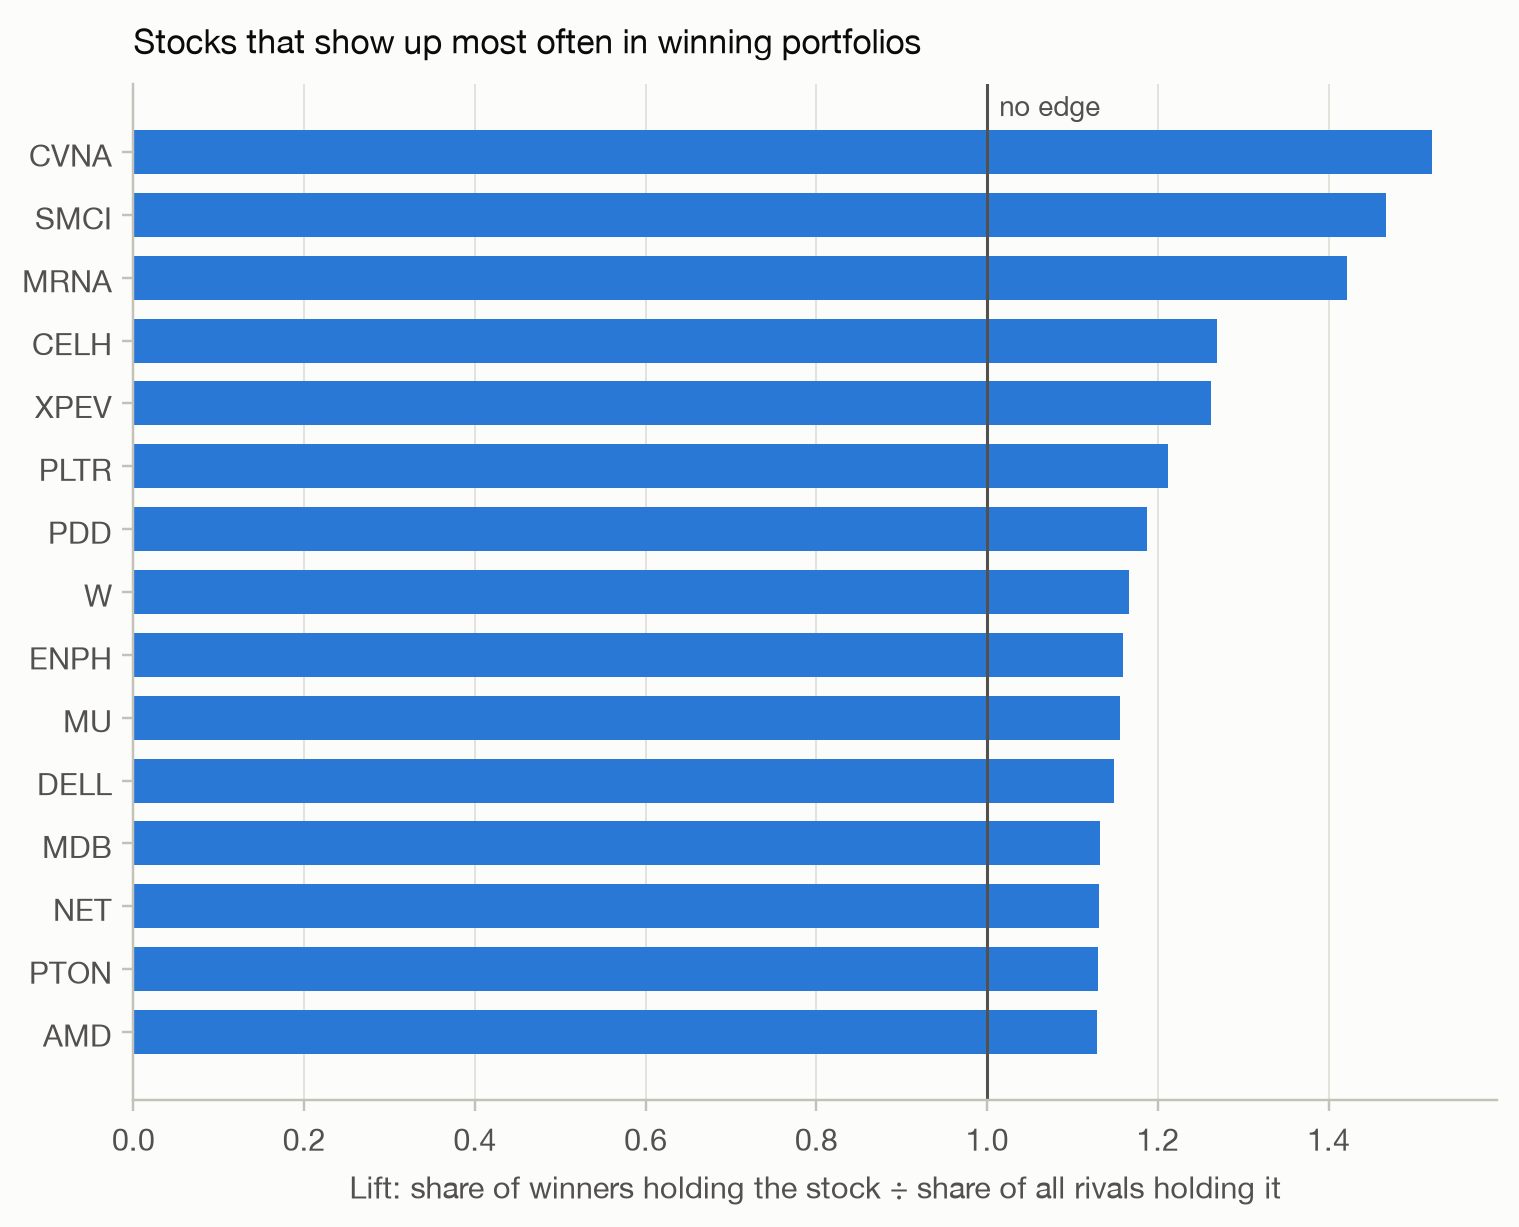


**What winning portfolios have in common**
- **Volatile stocks.** The 15 highest-lift stocks average **72%** annual volatility;
  the 15 lowest-lift stocks average 27%. Across the whole pool, lift and volatility
  have a correlation of 0.80.
- **Bigger bets on those stocks.** When a winner holds one of the 15 highest-lift stocks, it makes up
  **10.6%** of the portfolio on average, against 10.0% for rivals in general.
  Overall concentration differs little: winners keep 45% of their money in their three
  largest positions, typical rivals 44%. *Which* stocks get the big weights is what matters.
- **Our stocks.** Lift of our 10 picks: NVDA 1.10, SNAP 1.07, CAT 1.00, DE 0.99, AAPL 0.98, BSY 0.97, GOOGL 0.97, NEE 0.95, COST 0.94, JPM 0.92.


In [11]:
winners = screen.winner_table()
winners["annual_vol"] = stats.stock_stats(prices, POOL, BENCHMARK, HORIZON)["annual_vol"]
display(winners.head(15).style.set_caption("The 15 stocks with the highest lift (all views)")
        .format({"held by rivals": "{:.1%}", "held by winners": "{:.1%}", "lift": "{:.2f}",
                 "avg weight (rivals)": "{:.1%}", "avg weight (winners)": "{:.1%}", "annual_vol": "{:.0%}"}))
fig = charts.ranking_bars(winners["lift"].head(15), "Stocks that show up most often in winning portfolios",
                          "Lift: share of winners holding the stock ÷ share of all rivals holding it",
                          reference=1.0, reference_label="no edge")
charts.save_figure(fig, "winners_lift")
plt.show()

random_weights = rivals.random_bounded_weights((100_000, N), np.random.default_rng(SEED), MIN_WEIGHT, MAX_WEIGHT)
typical_top3 = np.sort(random_weights, axis=1)[:, -3:].sum(axis=1).mean()
top_lift, bottom_lift = winners.head(15), winners.tail(15)
winner_weight_top, rival_weight_top = top_lift["avg weight (winners)"].mean(), top_lift["avg weight (rivals)"].mean()
display(Markdown(f"""
**What winning portfolios have in common**
- **Volatile stocks.** The 15 highest-lift stocks average **{top_lift['annual_vol'].mean():.0%}** annual volatility;
  the 15 lowest-lift stocks average {bottom_lift['annual_vol'].mean():.0%}. Across the whole pool, lift and volatility
  have a correlation of {np.corrcoef(winners['lift'].to_numpy(), winners['annual_vol'].to_numpy())[0, 1]:.2f}.
- **Bigger bets on those stocks.** When a winner holds one of the 15 highest-lift stocks, it makes up
  **{winner_weight_top:.1%}** of the portfolio on average, against {rival_weight_top:.1%} for rivals in general.
  Overall concentration differs little: winners keep {screen.winner_top3_weight():.0%} of their money in their three
  largest positions, typical rivals {typical_top3:.0%}. *Which* stocks get the big weights is what matters.
- **Our stocks.** Lift of our 10 picks: {', '.join(f'{t} {winners.loc[t, "lift"]:.2f}' for t in
  winners.index if t in TICKERS)}.
"""))

## 6. Searching all 5.3 million allowed portfolios

On a 2.5% grid, the rules (10 stocks, 5–20% each, summing to 100%) allow exactly **5,266,030** portfolios. All of them are scored; there's no optimizer that could get stuck.

- **Stage 1 (screen):** every portfolio against 50,000 simulated futures in each view, on all CPU cores in parallel. The best 20,000 in each view move on.
- **Stage 2 (confirm):** the candidates are re-scored on **1,000,000 fresh futures**. Out of 5 million scores, the top ones are partly luck; fresh simulations remove that bias.
- The best candidate by P(win), averaged across views, is the grid pick.

(Quick mode uses a 5% grid and fewer simulations.)

In [12]:
units = search.enumerate_grid(N, MIN_WEIGHT, MAX_WEIGHT, GRID_STEP)
free_units = round((1 - N * MIN_WEIGHT) / GRID_STEP)
assert (units.sum(axis=1) == free_units).all(), "weights must sum to 100%"
assert units.max() * GRID_STEP <= MAX_WEIGHT - MIN_WEIGHT + 1e-9, "weights must stay within the limits"
if (N, MIN_WEIGHT, MAX_WEIGHT, GRID_STEP) == (10, 0.05, 0.20, 0.025):
    assert len(units) == 5_266_030
print(f"{len(units):,} allowed portfolios on a {GRID_STEP:.1%} grid")

cache_params = {"tickers": TICKERS, "pool": POOL, "last_date": LAST_DATE, "window_start": window_start,
                "settings": SETTINGS, "grid_step": GRID_STEP, "n_sims": N_SIMS_SCREEN, "seed": SEED}
stage1 = {}
for view in VIEWS:
    print(f"Stage 1 · {VIEW_LABELS[view]}")
    view_targets = targets[view].round(10).tolist() if view in targets.columns else None
    counts = cache.cached_npz(f"screen_{view}", cache.cache_key(view=view, targets=view_targets, **cache_params),
                              search.score_portfolios, units, MIN_WEIGHT, GRID_STEP, screen.returns_of(view, TICKERS),
                              screen.fields[view].best, screen.fields[view].third)
    stage1[view] = {k: counts[k].astype(np.float32) / N_SIMS_SCREEN for k in ("win", "top3", "loss")}

5,266,030 allowed portfolios on a 2.5% grid
Stage 1 · Neutral (CAPM)


   25% of 5,266,030 portfolios ·   16s


   50% of 5,266,030 portfolios ·   31s


   75% of 5,266,030 portfolios ·   47s


  100% of 5,266,030 portfolios ·   63s
Stage 1 · Momentum


...

  100% of 5,266,030 portfolios ·   63s
Stage 1 · Analyst targets


   25% of 5,266,030 portfolios ·   16s


   50% of 5,266,030 portfolios ·   32s


   75% of 5,266,030 portfolios ·   47s


  100% of 5,266,030 portfolios ·   63s
Stage 1 · Historical trend
  loaded cached results (screen_trend_0bbd9c693ef2.npz)


In [13]:
mu = np.stack([screen.returns_of(v, TICKERS).mean(axis=0, dtype=np.float64) for v in VIEWS])
cov = np.cov(screen.returns_of(VIEWS[0], TICKERS), rowvar=False)
means, stds = search.portfolio_moments(units, MIN_WEIGHT, GRID_STEP, mu, cov)
avg_mean = means @ screen.view_share.to_numpy(np.float32)
stage1_win = screen.average({v: stage1[v]["win"] for v in VIEWS})
stage1_loss = screen.average({v: stage1[v]["loss"] for v in VIEWS})

EQUAL = int(np.flatnonzero((units == free_units // N).all(axis=1))[0])
MAX_MEAN = int(np.argmax(avg_mean))
MAX_SHARPE = int(np.argmax((avg_mean - RISK_FREE_HORIZON) / stds))

candidate_set = {EQUAL, MAX_MEAN, MAX_SHARPE}
for view in VIEWS:
    candidate_set.update(np.argpartition(-stage1[view]["win"], TOP_K_CONFIRM)[:TOP_K_CONFIRM].tolist())
candidates = np.array(sorted(candidate_set))
print(f"{len(candidates):,} candidates carried into stage 2")

confirm = run_simulation(N_SIMS_CONFIRM, SEED + 1)
stage2 = confirm.evaluate(pd.DataFrame(search.weights_from_units(units[candidates], MIN_WEIGHT, GRID_STEP),
                                       columns=TICKERS, index=candidates), quantiles=False)
robust = pd.Series(stage2["P(win)"].to_numpy(), index=candidates)
GRID_PICK = int(candidates[int(np.argmax(robust.to_numpy()))])
grid_pick_weights = search.weights_from_units(units[GRID_PICK], MIN_WEIGHT, GRID_STEP)
print(f"Grid pick: {search.holdings_label(grid_pick_weights, TICKERS, MIN_WEIGHT)}"
      f" · P(win) {robust[GRID_PICK]:.2%} averaged across views")

41,311 candidates carried into stage 2


Grid pick: NVDA 20% · SNAP 20% · GOOGL 20% · AAPL 10% · P(win) 10.02% averaged across views


### Top 10 portfolios on the grid
Weights, P(win) averaged across views, and P(win) with its rank in each view. A portfolio that ranks near the top in every view doesn't depend on one particular forecast.

In [14]:
top = robust.nlargest(10).index
top_table = pd.DataFrame(search.weights_from_units(units[top.to_numpy()], MIN_WEIGHT, GRID_STEP), columns=TICKERS,
                         index=range(1, 11))
top_table["P(win) avg"] = robust.loc[top].to_numpy()
for view in VIEWS:
    column = f"P(win) {VIEW_LABELS[view]}"
    top_table[column] = stage2.loc[top, column].to_numpy()
    ranks = stage2[column].rank(ascending=False, method="min")
    top_table[f"rank {VIEW_LABELS[view]}"] = ranks.loc[top].astype(int).to_numpy()
probability_columns = pd.Index(["P(win) avg"] + [f"P(win) {VIEW_LABELS[v]}" for v in VIEWS])
display(top_table.style
        .background_gradient(cmap="Blues", subset=pd.Index(TICKERS), vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05)
        .format("{:.1%}", subset=pd.Index(TICKERS)).format("{:.2%}", subset=probability_columns))

stage_check = pd.DataFrame({
    VIEW_LABELS[v]: {"stage 1": stage1[v]["win"][top.to_numpy()].mean(),
                     "stage 2": stage2.loc[top, f"P(win) {VIEW_LABELS[v]}"].mean()}
    for v in VIEWS
}).T
stage_check["gap"] = stage_check["stage 1"] - stage_check["stage 2"]
display(stage_check.style.set_caption("Average P(win) of the top 10: stage 1 screen vs. fresh stage 2 simulations")
        .format("{:.2%}"))
if stage_check["gap"].abs().max() > 0.01:
    print("Note: stage 1 and stage 2 differ by more than 1 point; consider raising N_SIMS_SCREEN.")

,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST,P(win) avg,P(win) Neutral (CAPM),rank Neutral (CAPM),P(win) Momentum,rank Momentum,P(win) Analyst targets,rank Analyst targets,P(win) Historical trend,rank Historical trend
1,10.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,10.02%,9.66%,1,9.54%,1,10.19%,12,10.70%,24
2,7.5%,20.0%,7.5%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,9.95%,9.62%,3,9.46%,2,10.28%,9,10.46%,86
3,5.0%,20.0%,10.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,9.95%,9.64%,2,9.44%,3,10.44%,2,10.28%,212
4,7.5%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,7.5%,9.92%,9.54%,4,9.41%,4,10.13%,20,10.59%,37
5,5.0%,20.0%,7.5%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,7.5%,9.87%,9.51%,7,9.33%,7,10.25%,10,10.38%,140
6,7.5%,20.0%,5.0%,20.0%,5.0%,7.5%,5.0%,5.0%,20.0%,5.0%,9.86%,9.52%,6,9.40%,5,10.11%,26,10.42%,102
7,5.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,10.0%,9.85%,9.46%,11,9.30%,10,10.12%,23,10.52%,63
8,5.0%,20.0%,7.5%,20.0%,5.0%,7.5%,5.0%,5.0%,20.0%,5.0%,9.81%,9.49%,9,9.33%,8,10.23%,11,10.21%,283
9,7.5%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,7.5%,20.0%,5.0%,9.81%,9.38%,20,9.30%,9,9.98%,47,10.58%,40
10,5.0%,20.0%,5.0%,20.0%,5.0%,7.5%,5.0%,5.0%,20.0%,7.5%,9.78%,9.42%,14,9.27%,12,10.08%,34,10.34%,161


,stage 1,stage 2,gap
Neutral (CAPM),9.76%,9.52%,0.24%
Momentum,9.61%,9.38%,0.23%
Analyst targets,10.40%,10.18%,0.22%
Historical trend,10.69%,10.45%,0.24%


**How to read the second table:** if stage 1 scores were much higher than stage 2, the screen would be picking lucky portfolios. Gaps of a fraction of a point mean the screen is reliable.

### The trade-off: chance of winning vs. chance of losing money
Each gray dot is one of 40,000 randomly sampled allowed portfolios (stage 1, averaged across views).

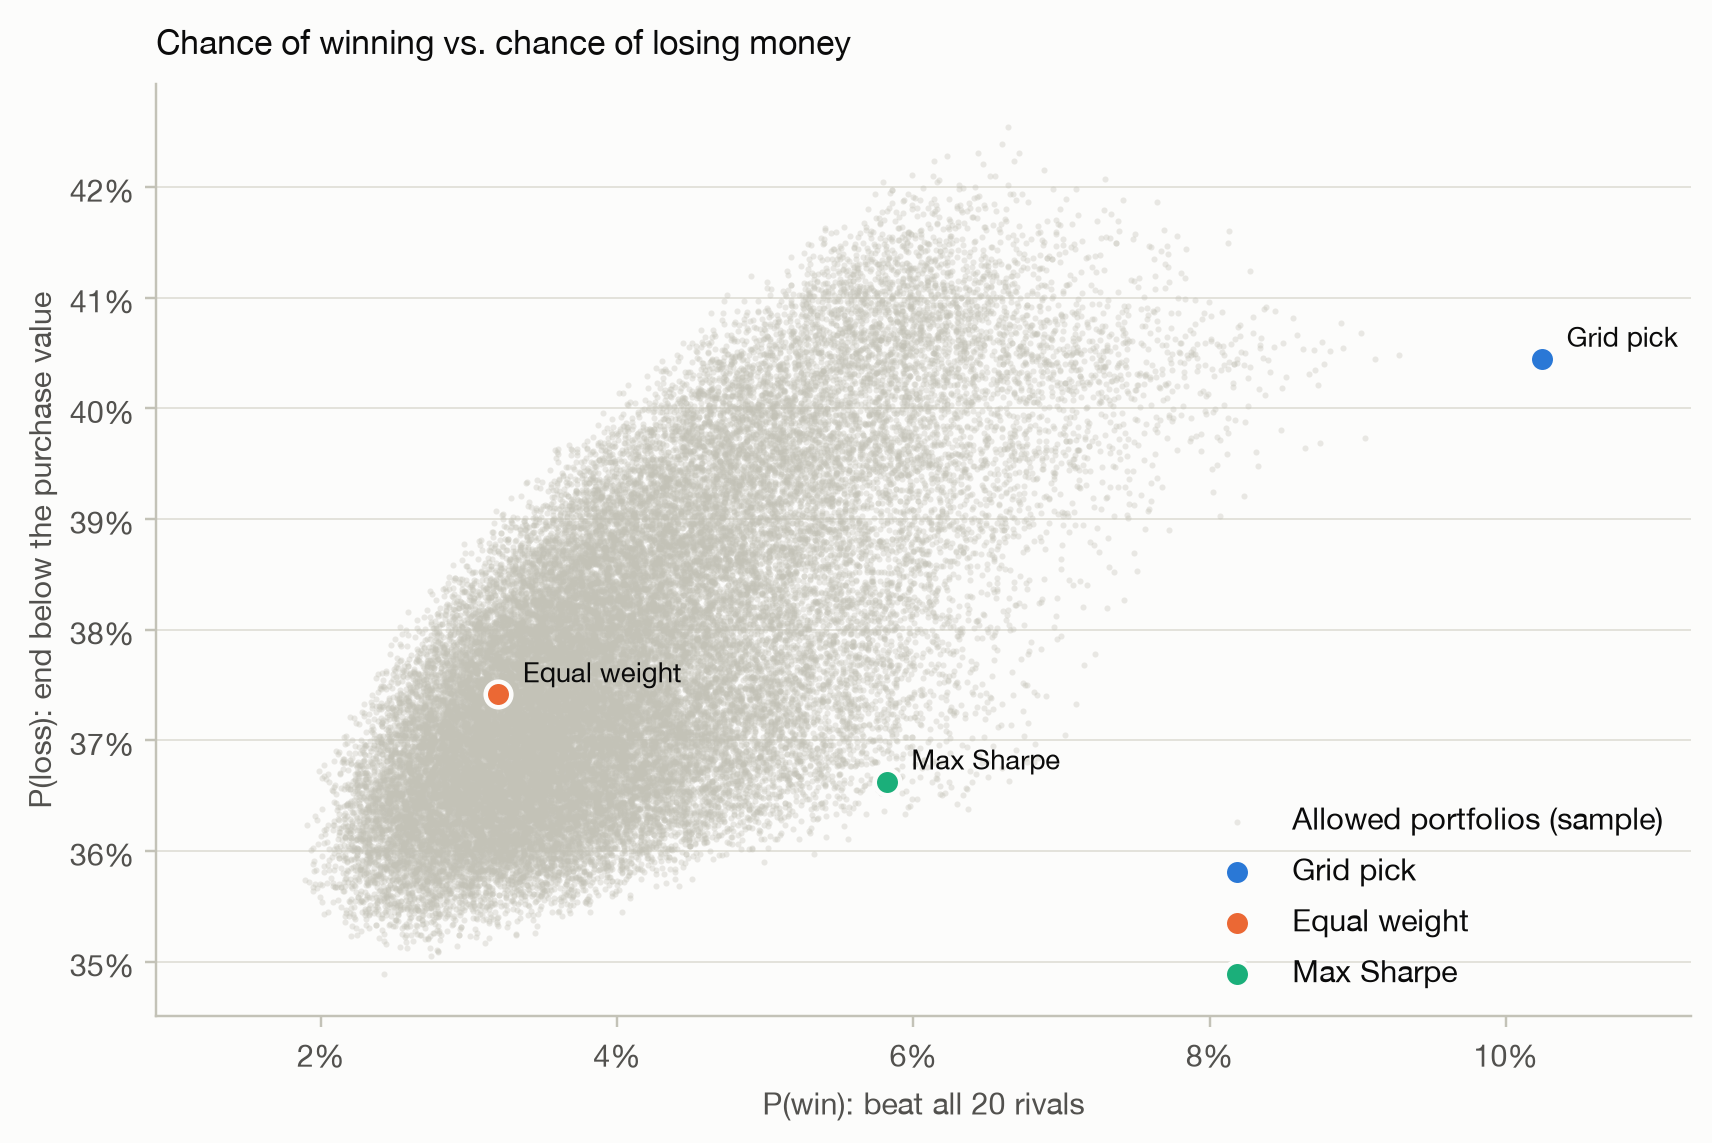

In [15]:
fig = charts.win_loss_scatter(stage1_win, stage1_loss,
                              {"Grid pick": GRID_PICK, "Equal weight": EQUAL, "Max Sharpe": MAX_SHARPE}, N_RIVALS,
                              seed=SEED)
charts.save_figure(fig, "win_vs_loss")
plt.show()

**How to read this chart:** further right means a better chance of finishing first; higher means a bigger chance of losing money. The best portfolios for winning sit at the far right, and they pay for it with a higher chance of a loss. Equal weight sits at the far left, and the textbook max-Sharpe portfolio lands in between.

## 7. Fine-tuning at 1% steps

The 2.5% grid is fairly coarse. Starting from the 25 best grid portfolios, the search now tries **moving 1% from any stock to any other**, keeps the best 25, and repeats until nothing improves (a *beam search*). Scores use the 1,000,000 stage 2 futures, averaged across views.

Tuning weights against one set of simulations can overfit its noise. So the grid pick and the fine-tuned pick are then compared on **another 1,000,000 fresh futures**, and the fine-tuned version is kept only if it holds up.

In [16]:
start_weights = search.weights_from_units(units[robust.nlargest(25).index.to_numpy()], MIN_WEIGHT, GRID_STEP)
fine_weights, fine_scores = search.refine_weights(start_weights, lambda rows: confirm.p_win(rows, TICKERS),
                                                  MIN_WEIGHT, MAX_WEIGHT, FINE_STEP)
print(f"Evaluated {len(fine_weights):,} fine-tuned portfolios")

validate = run_simulation(N_SIMS_CONFIRM, SEED + 2)
finalists = pd.DataFrame([grid_pick_weights.astype(float), fine_weights[0]], columns=TICKERS,
                         index=[f"Grid pick ({GRID_STEP:.1%} steps)", f"Fine-tuned ({FINE_STEP:.0%} steps)"])
validation = validate.evaluate(finalists, quantiles=False)
FINAL_NAME = str(validation["P(win)"].idxmax())
final_weights = pd.Series(finalists.loc[FINAL_NAME].to_numpy(), index=TICKERS).round(4)

display(finalists.style.set_caption("Weights")
        .background_gradient(cmap="Blues", vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05).format("{:.1%}"))
display(validation.style.set_caption("On fresh validation simulations").format("{:.2%}"))
print(f"Final choice: {FINAL_NAME} · {search.holdings_label(final_weights.to_numpy(), TICKERS, MIN_WEIGHT)}")

  round 1: 801 new portfolios · best score 10.021%
Evaluated 826 fine-tuned portfolios


,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST
Grid pick (2.5% steps),10.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%
Fine-tuned (1% steps),10.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%


,P(win),P(top 3),P(loss),mean,P(win) Neutral (CAPM),P(win) Momentum,P(win) Analyst targets,P(win) Historical trend
Grid pick (2.5% steps),10.07%,22.38%,40.43%,3.59%,9.72%,9.60%,10.24%,10.71%
Fine-tuned (1% steps),10.07%,22.38%,40.43%,3.59%,9.72%,9.60%,10.24%,10.71%


Final choice: Grid pick (2.5% steps) · NVDA 20% · SNAP 20% · GOOGL 20% · AAPL 10%


**How to read this:** the difference between the two is usually a small fraction of a percentage point. Finer weights polish the answer; the big decision (which stocks get the most money) was already made on the grid.

## 8. Comparison with standard portfolios

All portfolios are evaluated on the fresh validation futures, averaged across views:
- **Final pick:** from section 7
- **Equal weight:** 10% in each stock, the "no opinion" choice
- **Max Sharpe:** the best return per unit of risk, the textbook choice
- **Max expected return:** the highest average return
- **SPY:** the S&P 500, for reference (not allowed in the competition)

In [17]:
equal_weights = pd.Series(search.weights_from_units(units[EQUAL], MIN_WEIGHT, GRID_STEP), index=TICKERS)
contenders = pd.DataFrame({
    "Final pick": final_weights,
    "Equal weight": equal_weights,
    "Max Sharpe": search.weights_from_units(units[MAX_SHARPE], MIN_WEIGHT, GRID_STEP),
    "Max expected return": search.weights_from_units(units[MAX_MEAN], MIN_WEIGHT, GRID_STEP),
}, index=TICKERS).T.astype(float)
index_only = pd.DataFrame({BENCHMARK: [1.0]}, index=[BENCHMARK])
comparison = validate.evaluate(pd.concat([contenders, index_only]).fillna(0.0))
display(comparison.style.set_caption(f"Return over {HORIZON} trading days, all views").format("{:.1%}"))
display(contenders.style.set_caption("Weights")
        .background_gradient(cmap="Blues", vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05).format("{:.1%}"))

,P(win),P(top 3),P(loss),mean,5th pct,median,95th pct,P(win) Neutral (CAPM),P(win) Momentum,P(win) Analyst targets,P(win) Historical trend
Final pick,10.1%,22.4%,40.4%,3.6%,-18.4%,3.3%,26.7%,9.7%,9.6%,10.2%,10.7%
Equal weight,3.2%,12.3%,37.3%,3.2%,-13.9%,3.3%,20.1%,3.1%,3.0%,3.0%,3.5%
Max Sharpe,5.8%,18.2%,36.6%,4.0%,-14.7%,3.9%,23.2%,4.3%,4.6%,4.6%,9.8%
Max expected return,6.7%,19.4%,36.7%,4.0%,-14.9%,3.9%,23.5%,5.1%,5.4%,5.4%,10.8%
SPY,0.7%,5.7%,35.0%,2.7%,-10.0%,2.9%,14.7%,0.8%,0.8%,0.7%,0.4%


,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST
Final pick,10.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%
Equal weight,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%
Max Sharpe,5.0%,20.0%,5.0%,5.0%,15.0%,5.0%,5.0%,20.0%,15.0%,5.0%
Max expected return,5.0%,20.0%,5.0%,5.0%,10.0%,5.0%,5.0%,20.0%,20.0%,5.0%


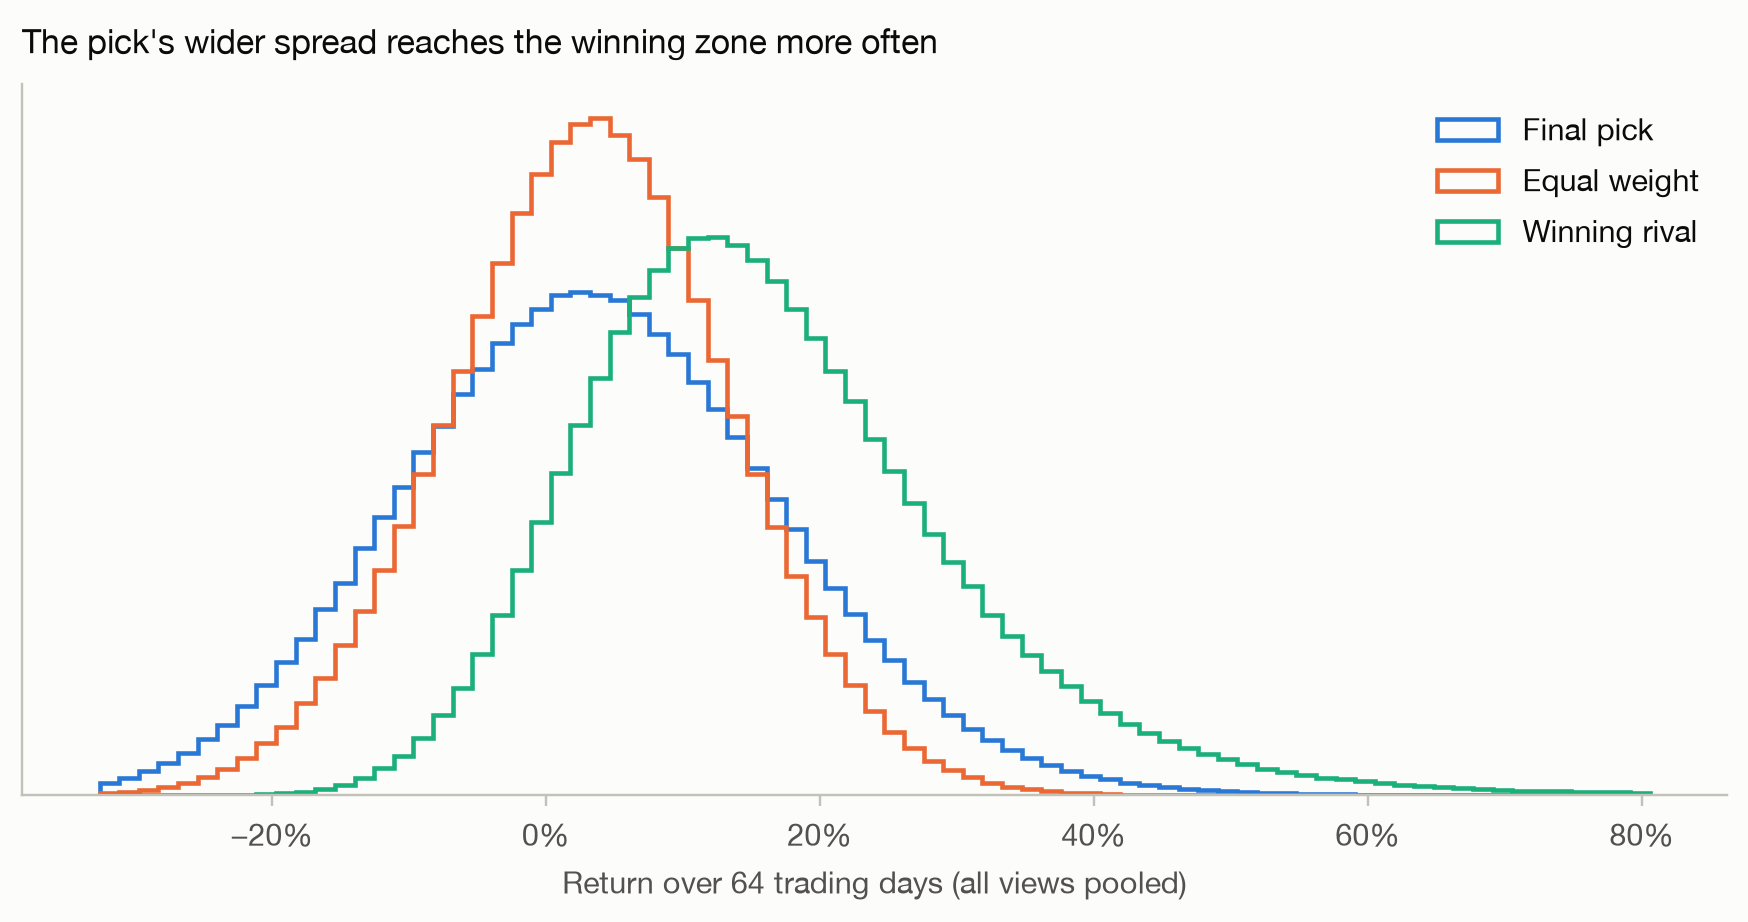

In [18]:
fig = charts.distributions({"Final pick": validate.pooled(final_weights),
                            "Equal weight": validate.pooled(equal_weights),
                            "Winning rival": validate.pooled_best()},
                           f"Return over {HORIZON} trading days (all views pooled)",
                           "The pick's wider spread reaches the winning zone more often")
charts.save_figure(fig, "winning_zone")
plt.show()

**How to read this chart:** the final pick (blue) and equal weight (orange) have about the same *typical* return, but the pick's distribution is wider. Its right tail reaches the returns that win the contest (aqua) much more often. The price is a fatter left tail: bigger losses are more likely too.

## 9. Free choice: the best 10 stocks from about 550

The assignment fixed our 10 stocks, but it's worth asking: **if any stocks had been allowed, what would the model pick, and how much would it help?**

- **Candidates:** the S&P 500 and Nasdaq-100 (a 2025 snapshot), meme and crypto-linked stocks (such as GME, AMC, MSTR and RIOT), our 10 and the rival pool, minus stocks without prices since 2020.
- **Simulation:** a separate 100,000-future simulation of all candidates against the same kind of rival field. It uses the neutral, momentum and trend views; analyst targets for about 550 stocks would take hundreds of slow downloads.
- **Search** (`stock_competition/picks.py`): find the best weights for a set of 10 stocks on a 5% grid, then the best single swap of one stock for any candidate; repeat while P(win) improves. The search starts twice, from our 10 stocks and from the 10 best single stocks, and keeps the better result. The winner's weights are then fine-tuned at 1% steps.
- **Validation:** the free-choice portfolio, our final pick and equal weight are compared on another 100,000 fresh futures.

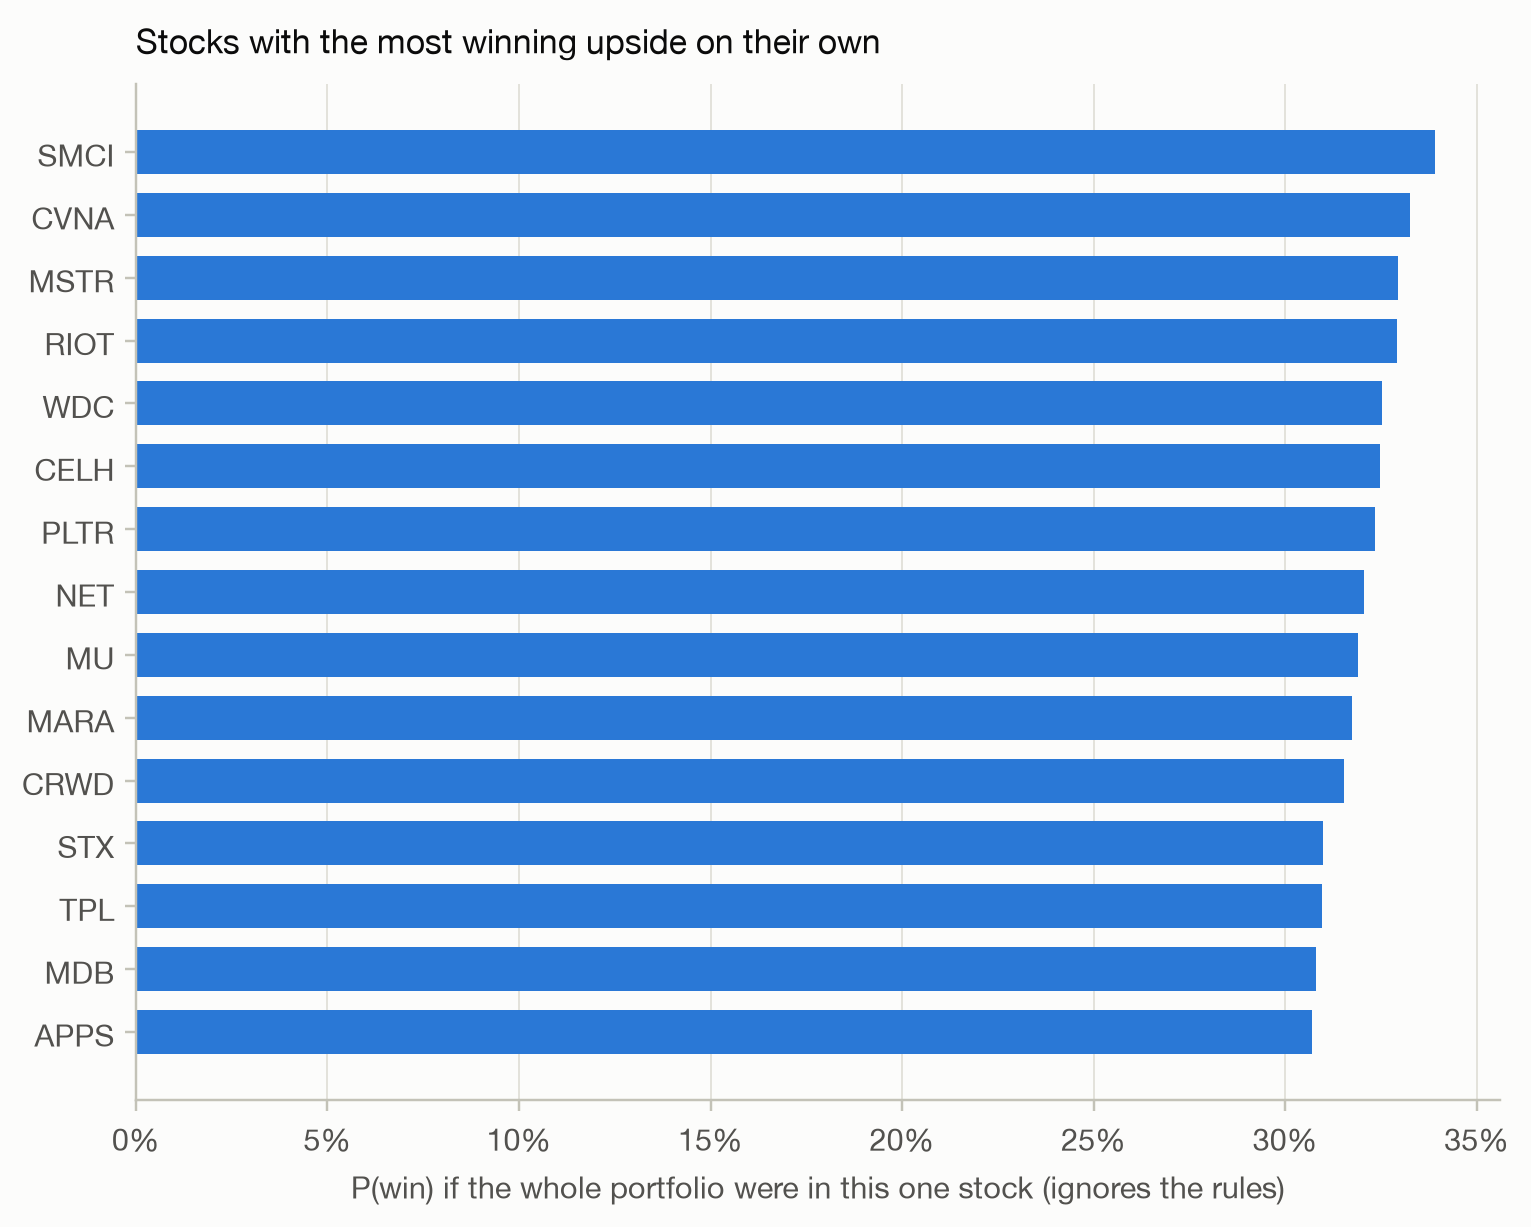

  Our 10 stocks · round 1: GOOGL → MARA · P(win) 19.19%


  Our 10 stocks · round 2: SNAP → MSTR · P(win) 25.20%


  Our 10 stocks · round 3: NVDA → RIOT · P(win) 28.25%


  Our 10 stocks · round 4: CAT → CVNA · P(win) 30.13%


  Our 10 stocks · round 5: NEE → CLSK · P(win) 30.95%


...

  Top 10 single stocks · round 1: CELH → CLSK · P(win) 33.05%


  Top 10 single stocks · round 2: WDC → GME · P(win) 33.36%


  Top 10 single stocks · round 3: SMCI → APPS · P(win) 33.50%


  Top 10 single stocks · round 4: MU → AMC · P(win) 33.58%


start,round,holdings,P(win)
Our 10 stocks,0,"GOOGL 20% · NVDA 20% · SNAP 20% · AAPL 10% · 5% each: BSY, CAT, COST, DE, JPM, NEE",10.07%
Our 10 stocks,1,"MARA 20% · NVDA 20% · SNAP 20% · AAPL 10% · 5% each: BSY, CAT, COST, DE, JPM, NEE",19.19%
Our 10 stocks,2,"MARA 20% · MSTR 20% · NVDA 20% · CAT 10% · 5% each: AAPL, BSY, COST, DE, JPM, NEE",25.20%
Our 10 stocks,3,"MARA 20% · MSTR 20% · RIOT 20% · CAT 10% · 5% each: AAPL, BSY, COST, DE, JPM, NEE",28.25%
Our 10 stocks,4,"CVNA 20% · MSTR 20% · RIOT 20% · MARA 10% · 5% each: AAPL, BSY, COST, DE, JPM, NEE",30.13%
Our 10 stocks,5,"CVNA 20% · MSTR 20% · RIOT 20% · MARA 10% · 5% each: AAPL, BSY, CLSK, COST, DE, JPM",30.95%
Our 10 stocks,6,"CVNA 20% · MSTR 20% · RIOT 20% · MARA 10% · 5% each: AAPL, CLSK, COST, DE, GME, JPM",31.72%
Our 10 stocks,7,"CVNA 20% · MSTR 20% · RIOT 20% · MARA 10% · 5% each: AAPL, CLSK, COST, GME, JPM, PLTR",32.30%
Our 10 stocks,8,"CVNA 20% · MSTR 20% · RIOT 20% · MARA 10% · 5% each: CLSK, COST, GME, JPM, NET, PLTR",32.76%
Our 10 stocks,9,"CVNA 20% · PLTR 20% · RIOT 20% · MSTR 10% · 5% each: APPS, CLSK, COST, GME, MARA, NET",33.18%


In [19]:
free_targets, _ = scenarios.drift_scenarios(candidate_prices, candidate_prices.columns, BENCHMARK, SETTINGS,
                                            RISK_FREE)
free_log_returns = stats.log_returns(candidate_prices).iloc[1:]


def run_free_simulation(seed, keep):
    """Simulate the competition for free-choice candidates; rivals still pick from the popular pool."""
    return simulation.simulate(free_log_returns, free_targets, SETTINGS, n_sims=N_SIMS_FREE, seed=seed, keep=keep,
                               pool=POOL, view_weights=FREE_VIEW_WEIGHTS)


free = run_free_simulation(SEED + 4, CANDIDATES)
single = picks.single_stock_win_rates(free, CANDIDATES)
charts.ranking_bars(single.head(15), "Stocks with the most winning upside on their own",
                    "P(win) if the whole portfolio were in this one stock (ignores the rules)", percent=True)
plt.show()

top_single = [str(t) for t in single.index.tolist()[:N]]
free_choice = picks.search_free_choice(free, CANDIDATES, {"Our 10 stocks": TICKERS, "Top 10 single stocks": top_single},
                                       MIN_WEIGHT, MAX_WEIGHT)
display(free_choice.history.style.set_caption("Search path: each row is one improving swap")
        .hide(axis="index").format({"P(win)": "{:.2%}"}))

,P(win),P(top 3),P(loss),mean,5th pct,median,95th pct,P(win) Neutral (CAPM),P(win) Momentum,P(win) Historical trend
Free choice,33.4%,39.7%,48.8%,9.9%,-45.6%,1.1%,94.9%,28.0%,27.8%,44.5%
Our final pick,9.9%,22.4%,39.8%,3.8%,-18.2%,3.5%,26.8%,9.6%,9.5%,10.7%
Equal weight (our stocks),3.1%,12.3%,36.3%,3.5%,-13.7%,3.6%,20.4%,2.9%,3.0%,3.5%


,weight,annual_return,annual_vol,beta,max_drawdown,P(win) alone,group
RIOT,20%,33.3%,104%,2.95,-96%,32.9%,speculative
PLTR,20%,64.0%,69%,2.05,-85%,32.4%,rival pool
CVNA,20%,10.5%,103%,3.32,-99%,33.3%,speculative
MSTR,10%,40.1%,93%,2.21,-89%,32.9%,speculative
NET,5%,34.0%,68%,2.22,-83%,32.1%,rival pool
GME,5%,35.7%,127%,0.39,-88%,21.2%,speculative
APPS,5%,-16.6%,103%,2.61,-99%,30.7%,speculative
CLSK,5%,7.6%,102%,2.33,-96%,30.1%,speculative
MARA,5%,27.8%,114%,3.13,-96%,31.7%,speculative
AMC,5%,-34.7%,134%,1.22,-100%,23.2%,speculative


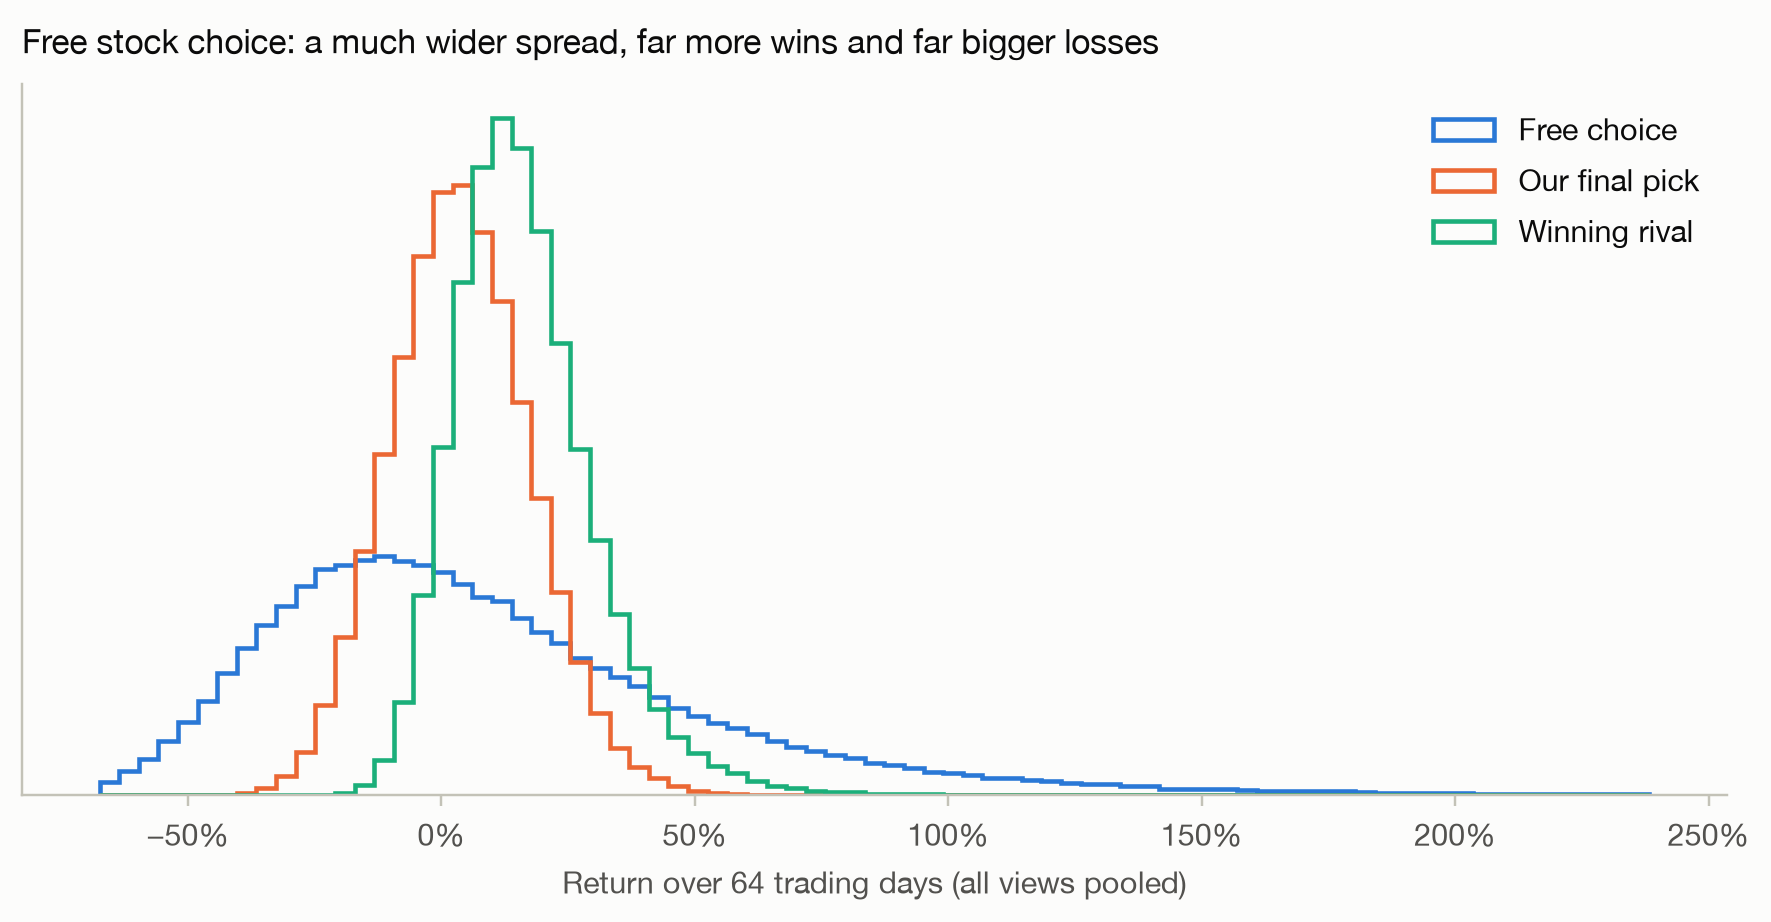

In [20]:
free_fine, _ = search.refine_weights(free_choice.weights[None, :],
                                     lambda rows: free.p_win(rows, free_choice.stocks),
                                     MIN_WEIGHT, MAX_WEIGHT, FINE_STEP, verbose=False)
free_weights = pd.Series(free_fine[0], index=free_choice.stocks).sort_values(ascending=False)
free_check = run_free_simulation(SEED + 5, list(dict.fromkeys(free_choice.stocks + TICKERS)))
free_portfolios = pd.DataFrame({
    "Free choice": free_weights,
    "Our final pick": final_weights,
    "Equal weight (our stocks)": pd.Series(0.1, index=TICKERS),
}).T.fillna(0.0)
free_comparison = free_check.evaluate(free_portfolios)
display(free_comparison.style.set_caption("On fresh simulations (neutral, momentum and trend views)")
        .format("{:.1%}"))

chosen = pd.DataFrame({"weight": free_weights}).join(
    stats.stock_stats(candidate_prices, list(free_weights.index), BENCHMARK, HORIZON)[
        ["annual_return", "annual_vol", "beta", "max_drawdown"]]
).join(single.rename("P(win) alone"))
chosen["group"] = ["speculative" if t in universe.SPECULATIVE_STOCKS else "rival pool" if t in POOL else "index"
                   for t in chosen.index]
display(chosen.style.set_caption("The free-choice portfolio")
        .format({"weight": "{:.0%}", "annual_return": "{:.1%}", "annual_vol": "{:.0%}", "beta": "{:.2f}",
                 "max_drawdown": "{:.0%}", "P(win) alone": "{:.1%}"}))

fig = charts.distributions({"Free choice": free_check.pooled(free_weights),
                            "Our final pick": free_check.pooled(final_weights),
                            "Winning rival": free_check.pooled_best()},
                           f"Return over {HORIZON} trading days (all views pooled)",
                           "Free stock choice: a much wider spread, far more wins and far bigger losses")
charts.save_figure(fig, "free_choice")
plt.show()

In [21]:
free_row, our_row = free_comparison.loc["Free choice"], free_comparison.loc["Our final pick"]
starts_agree = free_choice.history.groupby("start")["holdings"].last().nunique() == 1
display(Markdown(f"""
**What free choice would have bought**
- **{free_row['P(win)']:.0%} chance of winning** against {our_row['P(win)']:.0%} for our final pick on the same
  simulations: about **{free_row['P(win)'] / our_row['P(win)']:.1f}×** as likely to finish first.
- **The price:** a {free_row['P(loss)']:.0%} chance of losing money (our pick: {our_row['P(loss)']:.0%}) and a
  5th-percentile outcome of {free_row['5th pct']:+.0%} (our pick: {our_row['5th pct']:+.0%}).
- **What it holds:** {picks.portfolio_label(free_weights.to_numpy(), list(free_weights.index), MIN_WEIGHT)}. Average
  volatility {chosen['annual_vol'].mean():.0%}, against {stock_table.loc[TICKERS, 'annual_vol'].mean():.0%} for our 10
  stocks;
  {int((chosen['group'] == 'speculative').sum())} of the 10 are meme or crypto-linked stocks.
- **Robustness:** {"both starting points converged to the same portfolio" if starts_agree else
  "the two starting points ended in different portfolios; the better one is shown"}.

This is what the *model* rewards: extreme volatility that moves together. It says nothing about whether these companies
are good investments, and several of them have lost most of their value at some point.
"""))


**What free choice would have bought**
- **33% chance of winning** against 10% for our final pick on the same
  simulations: about **3.4×** as likely to finish first.
- **The price:** a 49% chance of losing money (our pick: 40%) and a
  5th-percentile outcome of -46% (our pick: -18%).
- **What it holds:** CVNA 20% · PLTR 20% · RIOT 20% · MSTR 10% · 5% each: AMC, APPS, CLSK, GME, MARA, NET. Average
  volatility 102%, against 36% for our 10
  stocks;
  8 of the 10 are meme or crypto-linked stocks.
- **Robustness:** both starting points converged to the same portfolio.

This is what the *model* rewards: extreme volatility that moves together. It says nothing about whether these companies
are good investments, and several of them have lost most of their value at some point.


## 10. How much do the rival assumptions matter?

The model needs a guess about what the classmates hold. It assumes each simulated rival picks from about 200 **well-known companies** (the *rival pool*), because that is what students tend to buy. The much longer list of about 550 stocks from section 9 was only used to search for *our* portfolio.

What if the classmates picked from the longer list too? This experiment re-runs the key numbers with three rival pools. All three use **identical simulated markets** (the same random draws), so any difference comes from the rivals alone:
1. **Popular stocks**, about 200: the model's assumption
2. **Popular + S&P 500 + Nasdaq-100**, about 520: adds hundreds of steady companies students rarely pick
3. **Everything, including meme and crypto stocks**, about 550

For each pool, the table shows what it takes to win, the chance of winning for three portfolios, and the best weights for our 10 stocks against those rivals (searched on a 5% grid).

In [22]:
index_additions = [t for t in CANDIDATES[len(POOL):] if t not in universe.SPECULATIVE_STOCKS]
rival_pools = {
    "Popular stocks (the model)": POOL,
    "+ S&P 500 and Nasdaq-100": POOL + index_additions,
    "+ meme and crypto (all candidates)": CANDIDATES,
}
coarse_units = search.enumerate_grid(N, MIN_WEIGHT, MAX_WEIGHT, 0.05)
experiment_rows = {}
for label, rival_pool in rival_pools.items():
    rival_test = simulation.simulate(free_log_returns, free_targets, SETTINGS, n_sims=N_SIMS_FREE, seed=SEED + 6,
                                     keep=list(free_portfolios.columns), pool=rival_pool,
                                     view_weights=FREE_VIEW_WEIGHTS)
    scores = rival_test.evaluate(free_portfolios, quantiles=False)
    best_our_weights, best_our_p_win = picks.best_weights(rival_test, TICKERS, coarse_units, MIN_WEIGHT, 0.05)
    winning = rival_test.pooled_best()
    experiment_rows[label] = {
        "stocks rivals pick from": len(rival_pool),
        "winning rival: median": float(np.median(winning)),
        "winning rival: 90th pct": float(np.percentile(winning, 90)),
        "P(win) our final pick": scores.loc["Our final pick", "P(win)"],
        "P(win) equal weight": scores.loc["Equal weight (our stocks)", "P(win)"],
        "P(win) free choice": scores.loc["Free choice", "P(win)"],
        "best weights for our 10": picks.portfolio_label(best_our_weights, TICKERS, MIN_WEIGHT),
        "P(win) with those weights": best_our_p_win,
    }
rival_experiment = pd.DataFrame(experiment_rows).T
experiment_percent = pd.Index([c for c in rival_experiment.columns if c.startswith(("winning", "P(win)"))])
display(rival_experiment.style
        .set_caption("Same simulated markets, different rival pools (neutral, momentum and trend views)")
        .format("{:.1%}", subset=experiment_percent).format("{:,.0f}", subset=pd.Index(["stocks rivals pick from"])))

,stocks rivals pick from,winning rival: median,winning rival: 90th pct,P(win) our final pick,P(win) equal weight,P(win) free choice,best weights for our 10,P(win) with those weights
Popular stocks (the model),205,14.9%,34.3%,10.0%,3.2%,33.5%,"GOOGL 20% · NVDA 20% · SNAP 20% · AAPL 10% · 5% each: BSY, CAT, COST, DE, JPM, NEE",10.0%
+ S&P 500 and Nasdaq-100,529,13.0%,27.8%,17.1%,6.9%,36.8%,"GOOGL 20% · NVDA 20% · SNAP 20% · AAPL 10% · 5% each: BSY, CAT, COST, DE, JPM, NEE",17.1%
+ meme and crypto (all candidates),555,14.7%,38.3%,13.1%,4.9%,32.5%,"GOOGL 20% · NVDA 20% · SNAP 20% · AAPL 10% · 5% each: BSY, CAT, COST, DE, JPM, NEE",13.1%


In [23]:
def moved(before, after):
    """'rises from X to Y' or 'falls from X to Y' for two fractions."""
    return f"{'rises' if after > before else 'falls'} from {before:.1%} to {after:.1%}"


base, broad, everything = (rival_experiment.iloc[i] for i in range(3))
same_weights = rival_experiment["best weights for our 10"].nunique() == 1
display(Markdown(f"""
**What the experiment shows**
- **Adding steady index companies:** the winning rival's median return {moved(base['winning rival: median'],
  broad['winning rival: median'])}, and our pick's chance of winning {moved(base['P(win) our final pick'],
  broad['P(win) our final pick'])}.
- **Adding meme and crypto stocks as well:** the winning rival's median return {moved(broad['winning rival: median'],
  everything['winning rival: median'])}, and our pick's chance of winning {moved(broad['P(win) our final pick'],
  everything['P(win) our final pick'])}.
- **Best weights for our 10 stocks:** {"the same against all three pools" if same_weights else
  "they shift with the rival pool: " + "; ".join(rival_experiment["best weights for our 10"].tolist())}.

**Why it works this way.** A winner-take-all contest is decided by the *luckiest* rival. Steady companies make the
luckiest rival less extreme, so a lower return wins; volatile meme and crypto stocks do the opposite. The chances in
this notebook are therefore estimates *under an assumption about the classmates*, not facts. If their real picks were
known, entering them in `RIVAL_UNIVERSE` would improve the model more than any other change.
"""))


**What the experiment shows**
- **Adding steady index companies:** the winning rival's median return falls from 14.9% to 13.0%, and our pick's chance of winning rises from 10.0% to 17.1%.
- **Adding meme and crypto stocks as well:** the winning rival's median return rises from 13.0% to 14.7%, and our pick's chance of winning falls from 17.1% to 13.1%.
- **Best weights for our 10 stocks:** the same against all three pools.

**Why it works this way.** A winner-take-all contest is decided by the *luckiest* rival. Steady companies make the
luckiest rival less extreme, so a lower return wins; volatile meme and crypto stocks do the opposite. The chances in
this notebook are therefore estimates *under an assumption about the classmates*, not facts. If their real picks were
known, entering them in `RIVAL_UNIVERSE` would improve the model more than any other change.


## 11. Backtest on past quarters

Would this method have worked before? For each past quarter (starting around the 14th of March, June, September and December), the search is re-run using **only data available on that date**: the neutral and momentum views (old analyst targets aren't available) on the full 2.5% grid. The pick is then scored on what actually happened over the next 64 trading days:
- **Percentile:** its rank among all 5.3 million allowed portfolios' actual returns (50% = average, 100% = best possible)
- **Field win rate:** the share of 20,000 random fields of 20 rivals, valued at their *actual* returns, that it beat

Two limits to keep in mind: about 18 quarters is a small sample, and the rival pool uses today's popular stocks, some of which soared, so the historical field is tougher than it looked at the time.

In [24]:
backtest_key = cache.cache_key(pool=POOL, last_date=LAST_DATE, window_start=window_start, settings=SETTINGS,
                               grid_step=BACKTEST_GRID_STEP, n_sims=BACKTEST_SIMS, seed=SEED)
history_test = cache.cached_frame("backtest", backtest_key, backtest.walk_forward, prices, TICKERS, RIVALS_KEPT,
                                  BENCHMARK, irx, SETTINGS, grid_step=BACKTEST_GRID_STEP, n_sims=BACKTEST_SIMS,
                                  seed=SEED + 3)
percent_columns = [c for c in history_test.columns if c not in ("end", "pick")]
display(history_test.style.format("{:.1%}", subset=pd.Index(percent_columns))
        .format(lambda d: f"{d:%Y-%m-%d}", subset=pd.Index(["end"])).format_index(lambda d: f"{d:%Y-%m-%d}"))

  loaded cached results (backtest_4050e9b012ec.pkl)


,end,pick,predicted_p_win,pick_return,equal_weight_return,max_sharpe_return,spy_return,pick_percentile,pick_field_win,equal_weight_field_win,max_sharpe_field_win,spy_field_win,field_winner_median
start,,,,,,,,,,,,,
2021-12-14,2022-03-17,AAPL 20% · NVDA 20% · COST 20% · NEE 10%,12.4%,-6.3%,-6.1%,-5.8%,-4.5%,47.7%,0.0%,0.0%,0.0%,0.1%,4.4%
2022-03-14,2022-06-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,11.7%,-23.7%,-17.6%,-14.7%,-10.1%,0.1%,0.0%,0.0%,0.0%,0.0%,4.0%
2022-06-14,2022-09-15,NVDA 20% · BSY 20% · SNAP 20% · COST 10%,12.5%,1.7%,4.1%,4.3%,4.8%,9.6%,0.0%,0.0%,0.0%,0.0%,23.7%
2022-09-14,2022-12-14,NVDA 20% · BSY 20% · SNAP 20% · COST 10%,12.4%,7.7%,7.2%,6.0%,1.6%,59.1%,0.6%,0.2%,0.0%,0.0%,13.6%
2022-12-14,2023-03-20,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 7.5% · COST 7.5%,10.9%,12.2%,5.0%,4.3%,-0.6%,100.0%,63.2%,0.8%,0.3%,0.0%,11.1%
2023-03-14,2023-06-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 7.5% · COST 7.5%,9.4%,27.0%,18.6%,18.5%,12.0%,99.0%,14.9%,0.2%,0.2%,0.0%,36.0%
2023-06-14,2023-09-15,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,10.0%,-1.0%,1.5%,3.0%,2.2%,1.3%,0.0%,0.0%,0.1%,0.0%,12.2%
2023-09-14,2023-12-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,10.8%,19.7%,11.3%,8.6%,5.2%,97.8%,73.2%,0.4%,0.0%,0.0%,17.5%
2023-12-14,2024-03-19,NVDA 20% · BSY 20% · SNAP 20% · AAPL 10%,10.7%,12.2%,11.1%,8.9%,10.0%,62.2%,0.6%,0.1%,0.0%,0.0%,24.0%


,average return,median return,field win rate,quarters beating equal weight
P(win) pick,5.4%,7.2%,14.0%,55.6%
Equal weight,4.8%,6.6%,5.2%,–
Max Sharpe,5.4%,6.6%,4.9%,50.0%
SPY,3.5%,4.4%,0.1%,38.9%


Random rival's field win rate (baseline): 4.8%
Pick's average predicted P(win): 10.8% · actual field win rate: 14.0%
Quarters in which the pick beat more than 5% of random fields: 4 of 18


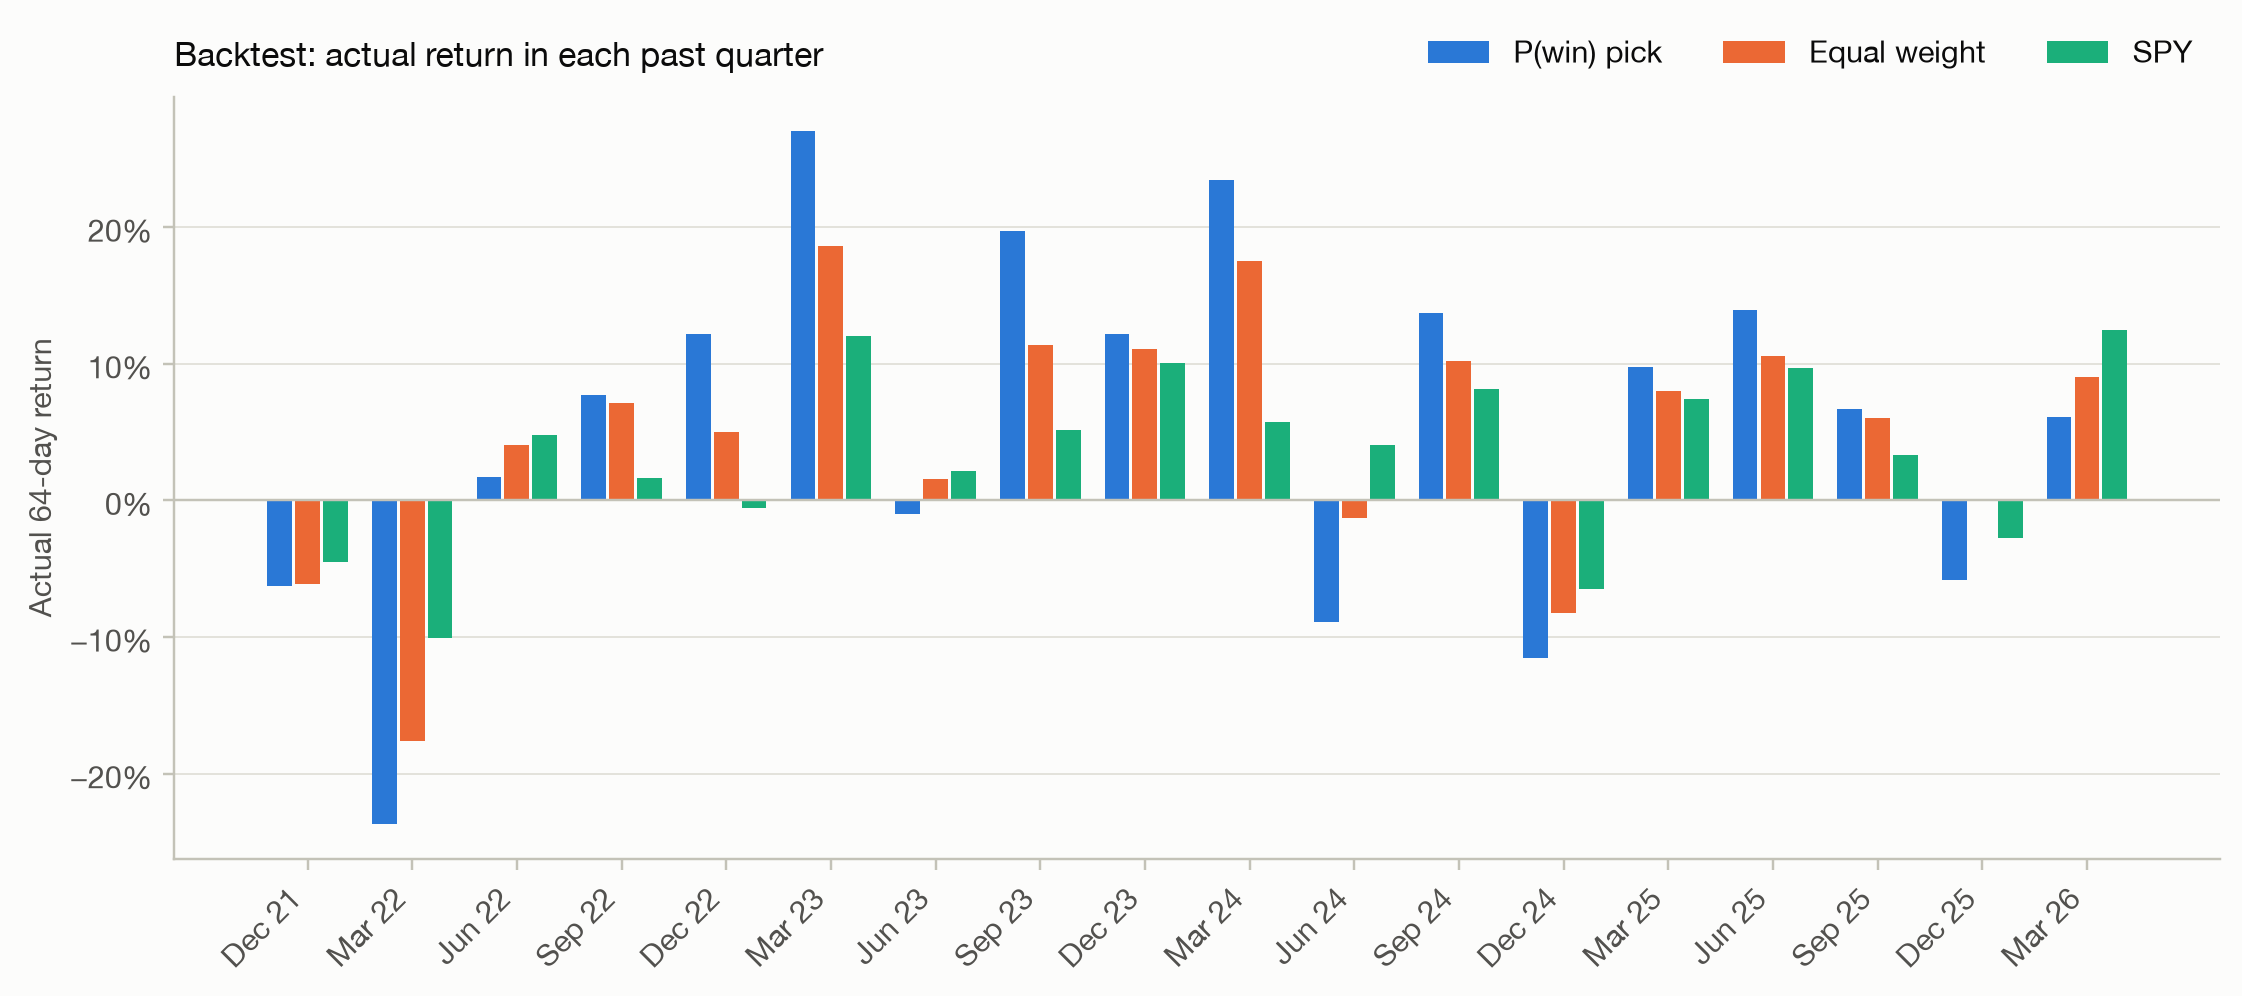

In [25]:
QUARTERS = len(history_test)
strategies = {"pick": "P(win) pick", "equal_weight": "Equal weight", "max_sharpe": "Max Sharpe", "spy": BENCHMARK}
backtest_summary = pd.DataFrame({
    label: {
        "average return": history_test[f"{key}_return"].mean(),
        "median return": history_test[f"{key}_return"].median(),
        "field win rate": history_test[f"{key}_field_win"].mean(),
        "quarters beating equal weight": (np.nan if key == "equal_weight" else
                                          (history_test[f"{key}_return"] > history_test["equal_weight_return"]).mean()),
    }
    for key, label in strategies.items()
}).T
display(backtest_summary.style.set_caption(f"{QUARTERS} quarters").format("{:.1%}", na_rep="–"))
WINNING_QUARTERS = int((history_test["pick_field_win"] > 0.05).sum())
print(f"Random rival's field win rate (baseline): {1 / (N_RIVALS + 1):.1%}")
print(f"Pick's average predicted P(win): {history_test['predicted_p_win'].mean():.1%} · "
      f"actual field win rate: {history_test['pick_field_win'].mean():.1%}")
print(f"Quarters in which the pick beat more than 5% of random fields: {WINNING_QUARTERS} of {QUARTERS}")

bars = history_test.reindex(columns=["pick_return", "equal_weight_return", "spy_return"])
bars.columns = pd.Index([strategies["pick"], strategies["equal_weight"], BENCHMARK])
fig = charts.grouped_bars(bars, f"Actual {HORIZON}-day return", "Backtest: actual return in each past quarter")
charts.save_figure(fig, "backtest")
plt.show()

**How to read this chart:** each group of bars is one past quarter. The pick's bars are usually the tallest in strong markets and the deepest in weak ones: it amplifies whatever the market does, which is exactly the behavior that wins contests (and loses them).

## 12. Final allocation

Dollar amounts come from the final pick's weights. Share counts use the **latest closing price** as a reference; the actual counts depend on the price paid on Sep 14. The allocation is saved to `results/allocation.csv`, which the tracking notebook reads.

In [26]:
allocation = pd.DataFrame({
    "ticker": TICKERS,
    "weight": final_weights.to_numpy(),
    "dollars": (CAPITAL * final_weights).round(2).to_numpy(),
    "ref_price": prices[TICKERS].iloc[-1].round(2).to_numpy(),
})
allocation["shares"] = (allocation["dollars"] / allocation["ref_price"]).round(4)
allocation["ref_date"] = f"{LAST_DATE:%Y-%m-%d}"
allocation = allocation.sort_values(["weight", "ticker"], ascending=[False, True]).reset_index(drop=True)

assert np.isclose(allocation["weight"].sum(), 1.0, atol=1e-6)
assert allocation["weight"].between(MIN_WEIGHT - 1e-9, MAX_WEIGHT + 1e-9).all()
assert np.isclose(allocation["dollars"].sum(), CAPITAL, atol=0.01)
RESULTS_DIR.mkdir(exist_ok=True)
allocation.to_csv(RESULTS_DIR / "allocation.csv", index=False)

display(allocation.style.hide(axis="index")
        .set_caption(f"Capital ${CAPITAL:,.0f} · reference prices from {LAST_DATE:%Y-%m-%d}")
        .format({"weight": "{:.1%}", "dollars": "${:,.2f}", "ref_price": "${:,.2f}", "shares": "{:,.4f}"}))

pick_row, equal_row = comparison.loc["Final pick"], comparison.loc["Equal weight"]
display(Markdown(f"""
| | Final pick | Equal weight |
| --- | --- | --- |
| Chance of finishing 1st of {N_RIVALS + 1} | **{pick_row['P(win)']:.1%}** | {equal_row['P(win)']:.1%} |
| Chance of finishing in the top 3 | {pick_row['P(top 3)']:.1%} | {equal_row['P(top 3)']:.1%} |
| Chance of losing money | {pick_row['P(loss)']:.1%} | {equal_row['P(loss)']:.1%} |
| Median 3-month return | {pick_row['median']:+.1%} | {equal_row['median']:+.1%} |
| Bad case (5th percentile) | {pick_row['5th pct']:+.1%} | {equal_row['5th pct']:+.1%} |
| Good case (95th percentile) | {pick_row['95th pct']:+.1%} | {equal_row['95th pct']:+.1%} |

A random rival's chance of finishing first is {1 / (N_RIVALS + 1):.1%}.
"""))

ticker,weight,dollars,ref_price,shares,ref_date
GOOGL,20.0%,"$20,000.00",$338.50,59.0842,2026-09-11
NVDA,20.0%,"$20,000.00",$218.29,91.6212,2026-09-11
SNAP,20.0%,"$20,000.00",$5.68,"3,521.1268",2026-09-11
AAPL,10.0%,"$10,000.00",$332.27,30.0960,2026-09-11
BSY,5.0%,"$5,000.00",$30.97,161.4466,2026-09-11
CAT,5.0%,"$5,000.00",$818.57,6.1082,2026-09-11
COST,5.0%,"$5,000.00",$904.77,5.5263,2026-09-11
DE,5.0%,"$5,000.00",$675.74,7.3993,2026-09-11
JPM,5.0%,"$5,000.00",$356.23,14.0359,2026-09-11
NEE,5.0%,"$5,000.00",$82.31,60.7460,2026-09-11



| | Final pick | Equal weight |
| --- | --- | --- |
| Chance of finishing 1st of 21 | **10.1%** | 3.2% |
| Chance of finishing in the top 3 | 22.4% | 12.3% |
| Chance of losing money | 40.4% | 37.3% |
| Median 3-month return | +3.3% | +3.3% |
| Bad case (5th percentile) | -18.4% | -13.9% |
| Good case (95th percentile) | +26.7% | +20.1% |

A random rival's chance of finishing first is 4.8%.


## 13. What we learned

In [27]:
heavy = [str(t) for t, weight in final_weights.sort_values(ascending=False).items() if weight >= 0.15]
others = [t for t in TICKERS if t not in heavy]
heavy_profile = ", ".join(
    f"{t} ({stock_table.loc[t, 'annual_vol']:.0%} volatility, beta {stock_table.loc[t, 'beta']:.1f})" for t in heavy
)
weights_note = (" The best weights for our 10 stocks stayed the same in every pool, so the recommendation holds up "
                "even though the chances move." if same_weights else
                " The best weights for our 10 stocks also shift with the rival pool.")
fine_sentence = (f"Fine-tuning from {GRID_STEP:.1%} to {FINE_STEP:.0%} steps raised P(win) by "
                 f"{(validation['P(win)'].iloc[1] - validation['P(win)'].iloc[0]) * 100:.2f} percentage points "
                 "on fresh "
                 "simulations, so the fine-tuned weights were kept."
                 if FINAL_NAME.startswith("Fine") else
                 f"Fine-tuning from {GRID_STEP:.1%} to {FINE_STEP:.0%} steps did not beat the grid pick on fresh "
                 "simulations, so the simpler grid weights were kept.")
display(Markdown(f"""
**1. Winning and investing well are different goals.** The final pick and equal weight have almost the same median
return ({pick_row['median']:+.1%} vs {equal_row['median']:+.1%}), yet the pick is about
**{pick_row['P(win)'] / equal_row['P(win)']:.1f}× as likely to finish first** ({pick_row['P(win)']:.1%} vs
{equal_row['P(win)']:.1%}). The price: a {pick_row['P(loss)']:.0%} chance of losing money
(equal weight: {equal_row['P(loss)']:.0%}).

**2. Volatility is the main lever, not forecasts.** The biggest positions are {heavy_profile}. The other
{len(others)} stocks average {stock_table.loc[others, 'annual_vol'].mean():.0%} volatility and beta
{stock_table.loc[others, 'beta'].mean():.1f}. The winner analysis says the same from the other side: the stocks winning
rivals hold most often average {top_lift['annual_vol'].mean():.0%} volatility, and winners give those stocks bigger
weights ({winner_weight_top:.1%} vs {rival_weight_top:.1%} for rivals in general).

**3. Stock choice matters far more than weights.** Re-weighting our 10 stocks lifted P(win) from
{equal_row['P(win)']:.1%} to {pick_row['P(win)']:.1%}. Free choice of stocks would have reached about
{free_row['P(win)']:.0%} on the free-choice simulations (where our pick scores {our_row['P(win)']:.0%}), by filling
the portfolio with the most volatile stocks available.

**4. Diversification narrows both tails.** Spreading money evenly makes a large loss less likely, but it also
makes a first-place finish unlikely. That is great for real savings and poor for a winner-take-all contest.

**5. The history test is encouraging but not proof.** Over {QUARTERS} past quarters the P(win) pick beat random
rival fields {history_test['pick_field_win'].mean():.1%} of the time, against
{history_test['equal_weight_field_win'].mean():.1%} for equal weight and
{1 / (N_RIVALS + 1):.1%} for a random rival. But the wins came from only {WINNING_QUARTERS} strong quarters, and its
average return ({history_test['pick_return'].mean():+.1%} per quarter) was close to equal weight
({history_test['equal_weight_return'].mean():+.1%}). It wins by occasionally finishing far ahead, not by earning more.

**6. The chances depend on who the rivals are.** If the classmates picked from all ~550 candidates instead of ~200
popular stocks, our pick's chance of winning {moved(base['P(win) our final pick'], everything['P(win) our final pick'])}
(section 10).{weights_note} The numbers are estimates under an assumption about the classmates, not facts.

**7. Precision has limits.** {fine_sentence} With 3-month returns this noisy, the useful decisions are the big
ones: which stocks get the most money.
"""))


**1. Winning and investing well are different goals.** The final pick and equal weight have almost the same median
return (+3.3% vs +3.3%), yet the pick is about
**3.2× as likely to finish first** (10.1% vs
3.2%). The price: a 40% chance of losing money
(equal weight: 37%).

**2. Volatility is the main lever, not forecasts.** The biggest positions are NVDA (50% volatility, beta 2.0), SNAP (77% volatility, beta 1.6), GOOGL (31% volatility, beta 1.2). The other
7 stocks average 29% volatility and beta
0.9. The winner analysis says the same from the other side: the stocks winning
rivals hold most often average 72% volatility, and winners give those stocks bigger
weights (10.6% vs 10.0% for rivals in general).

**3. Stock choice matters far more than weights.** Re-weighting our 10 stocks lifted P(win) from
3.2% to 10.1%. Free choice of stocks would have reached about
33% on the free-choice simulations (where our pick scores 10%), by filling
the portfolio with the most volatile stocks available.

**4. Diversification narrows both tails.** Spreading money evenly makes a large loss less likely, but it also
makes a first-place finish unlikely. That is great for real savings and poor for a winner-take-all contest.

**5. The history test is encouraging but not proof.** Over 18 past quarters the P(win) pick beat random
rival fields 14.0% of the time, against
5.2% for equal weight and
4.8% for a random rival. But the wins came from only 4 strong quarters, and its
average return (+5.4% per quarter) was close to equal weight
(+4.8%). It wins by occasionally finishing far ahead, not by earning more.

**6. The chances depend on who the rivals are.** If the classmates picked from all ~550 candidates instead of ~200
popular stocks, our pick's chance of winning rises from 10.0% to 13.1%
(section 10). The best weights for our 10 stocks stayed the same in every pool, so the recommendation holds up even though the chances move. The numbers are estimates under an assumption about the classmates, not facts.

**7. Precision has limits.** Fine-tuning from 2.5% to 1% steps did not beat the grid pick on fresh simulations, so the simpler grid weights were kept. With 3-month returns this noisy, the useful decisions are the big
ones: which stocks get the most money.


## 14. Lessons, caveats and experiments to try

**Lessons for future stock-picking assignments**
1. **Start from the rules.** How the contest is scored (highest return, risk-adjusted return, beating an index) decides which portfolio is "best".
2. **Back each reason with data.** A sector check, a correlation table and a volatility figure turn "I think" into "the data shows".
3. **Treat diversification as a decision.** Know what it buys (fewer disasters) and what it costs (fewer big wins).
4. **Give ranges, not point forecasts.** "Somewhere between −20% and +25%" is more honest and more useful than "+5%".
5. **Test ideas on history, and report the result honestly,** including when the evidence is thin.

**Caveats**
- **This is a model, not a guarantee.** Three-month returns are mostly noise. The notebook improves the odds; even the best portfolio loses the contest most of the time.
- **The rivals are guesses.** Real classmates' stocks and weights are unknown. Section 10 shows how much the chances move when rivals pick from a different list.
- **History has limits.** The window (late 2020 to today) includes an AI-driven boom in tech stocks, a crypto boom and bust, the 2022 bear market and unusually high volatility for growth stocks.
- **The free-choice portfolio is a thought experiment.** It is what maximizes the contest odds in this model, not a recommendation to buy those stocks.
- **Educational project, not investment advice.**

**Experiments** (change a setting in section 1, then run all cells)
- Set `HALF_LIFE_YEARS = 2` to weight recent years more. Does the pick change?
- Set `N_RIVALS = 5` or `50`. With fewer rivals, does a less aggressive portfolio win more often?
- Set `VIEW_WEIGHTS = {"neutral": 1, "momentum": 0, "analyst": 0, "trend": 0}` to rely on CAPM alone.
- Set `MAX_WEIGHT = 0.30` to see how much more concentrated the pick becomes when the rules allow it.
- Remove `universe.SPECULATIVE_STOCKS` from `CANDIDATE_UNIVERSE` to see the best free-choice portfolio from established companies only.
- Set `RIVAL_UNIVERSE = CANDIDATE_UNIVERSE` to run the whole analysis, including the weight search, against rivals who pick from every candidate.